<a href="https://colab.research.google.com/github/314sirius/Space-ML-Analytics/blob/main/02-Satellite-Reliability-RSF/Satellite_SurvivalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lifelines

In [ ]:
!pip install scikit-survival

In [ ]:
import os

if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')

path = '/content/drive/MyDrive/Space/SatelliteSurvival/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

filepath = path+'satellite_survival_data_1990.csv'

data=pd.read_csv(filepath)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18987 entries, 0 to 18986
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #JCAT         18987 non-null  object 
 1   Satcat        18987 non-null  object 
 2   Launch_Tag    18987 non-null  object 
 3   Piece         18987 non-null  object 
 4   Type          18987 non-null  object 
 5   Name          18987 non-null  object 
 6   PLName        18987 non-null  object 
 7   LDate         18987 non-null  object 
 8   Parent        18987 non-null  object 
 9   SDate         18987 non-null  object 
 10  Primary       18987 non-null  object 
 11  Status        18987 non-null  object 
 12  Owner         18987 non-null  object 
 13  State         18987 non-null  object 
 14  Manufacturer  18987 non-null  object 
 15  Bus           18987 non-null  object 
 16  Mass          18987 non-null  float64
 17  DryMass       18987 non-null  float64
 18  TotMass       18987 non-nu

In [ ]:
import pandas as pd
import numpy as np

df_clean = data.copy()

# List of all text (categorical) columns where missing values are hidden
object_cols = df_clean.select_dtypes(include=['object']).columns

# Replace hidden empty values with actual NaNs
for col in object_cols:
    # Convert to string, remove leading/trailing spaces
    df_clean[col] = df_clean[col].astype(str).str.strip()

    # Replace all McDowell's empty markers with np.nan
    df_clean[col] = df_clean[col].replace(['-', '?', 'NaT', 'nan', 'None', ''], np.nan)

# Check how many actual missing values now appear in text columns
print("New count of actual missing values by column:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

New count of actual missing values by column:
PLName           27
Bus             228
Shape             8
ODate             5
OpOrbit           5
Launch_Pad       72
DDate1        15918
dtype: int64


In [ ]:
# Average equatorial Earth radius (km)
R_E = 6378.1

df_clean['Eccentricity'] = (df_clean['Apogee'] - df_clean['Perigee']) / (df_clean['Apogee'] + df_clean['Perigee'] + 2 * R_E)

In [ ]:
df_clean.head().T

,0,1,2,3,4
#JCAT,S20401,S20402,S20410,S20432,S20436
Satcat,20401,20402,20410,20432,20436
Launch_Tag,1990-001,1990-001,1990-002,1990-004,1990-005
Piece,1990-001A,1990-001B,1990-002B,1990-004A,1990-005A
Type,P,P,P ---S-,P,P
Name,Skynet 4A,JCSAT 2,Leasat 5,Kosmos-2056,SPOT 2
PLName,Skynet 4A,JCSAT 2,Syncom IV-5,Strela-2M No. 57L,SPOT 2
LDate,1990-01-01,1990-01-01,1990-01-09,1990-01-18,1990-01-22
Parent,S20405,S20403,A04775,S20433,S20443
SDate,1990 Jan 1 0118,1990 Jan 1 0251,1990 Jan 10 1318,1990 Jan 18 1326?,1990 Jan 22 0152


# Correlation

### Spearman

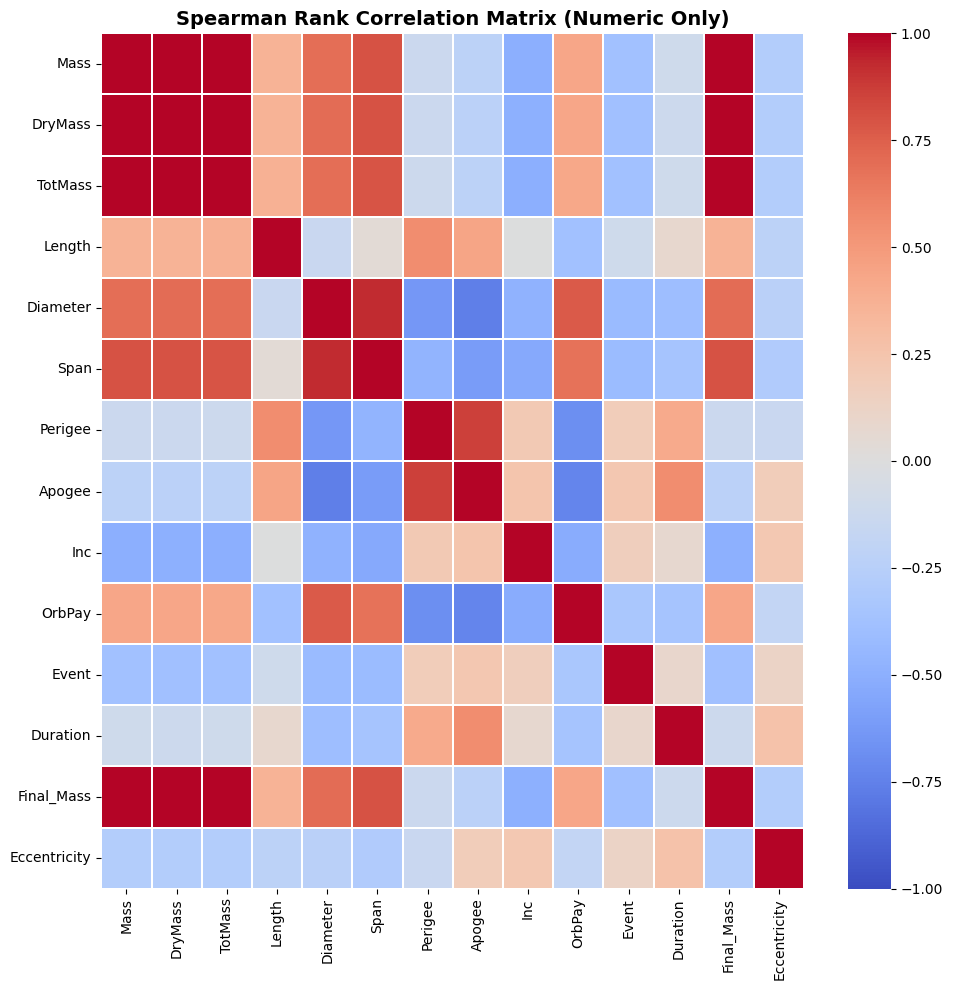

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate correlation strictly for numeric columns (numeric_only=True)
# The 'spearman' method is better at catching non-linear dependencies (like between DryMass and Span)
corr_matrix = df_clean.corr(method='spearman', numeric_only=True)

# 2. Visualize
plt.figure(figsize=(10, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.1,
    vmax=1,
    vmin=-1,
    center=0
)

plt.title('Spearman Rank Correlation Matrix (Numeric Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def find_correlations(mat, threshold):
    # Keep only the upper triangle (excluding the diagonal) to avoid duplicates and self-correlation
    cor_pairs = mat.stack().reset_index()
    cor_pairs.columns = ['var1', 'var2', 'cor_value']

    # Ensure var1 < var2 to keep only one instance of each pair
    cor_pairs = cor_pairs[cor_pairs['var1'] < cor_pairs['var2']]

    # Filter by absolute correlation value
    highly_correlated_pairs = cor_pairs[abs(cor_pairs['cor_value']) > threshold]

    # Sort by absolute correlation value in descending order
    highly_correlated_pairs = highly_correlated_pairs.sort_values(by='cor_value', ascending=False, key=abs)

    return highly_correlated_pairs

# Find pairs with correlation > 0.5
highly_correlated = find_correlations(corr_matrix, threshold = 0.7)

print("Variable pairs with correlation coefficient above 0.7 (can lead to high VIF):\n")
highly_correlated

Variable pairs with correlation coefficient above 0.7 (can lead to high VIF):



,var1,var2,cor_value
26,DryMass,Final_Mass,1.000000
2,Mass,TotMass,0.999110
14,DryMass,Mass,0.996879
168,Final_Mass,Mass,0.996879
16,DryMass,TotMass,0.995553
170,Final_Mass,TotMass,0.995553
61,Diameter,Span,0.923435
104,Apogee,Perigee,0.861501
19,DryMass,Span,0.800316
173,Final_Mass,Span,0.800316


In [ ]:
features_to_drop = [
    'Apogee',                         # Duplicates Perigee on circular orbits
    'Span',                           # Duplicates DryMass and geometry
    'Mass', 'TotMass', 'Final_Mass',  # Absolute collinear duplicates of DryMass
    'OrbPay'                          # Duplicates apparatus class and is collinear with diameter
]

df_clean = df_clean.drop(columns=[col for col in features_to_drop if col in df_clean.columns], axis=1)
corr_matrix = df_clean.corr(method='spearman', numeric_only=True)

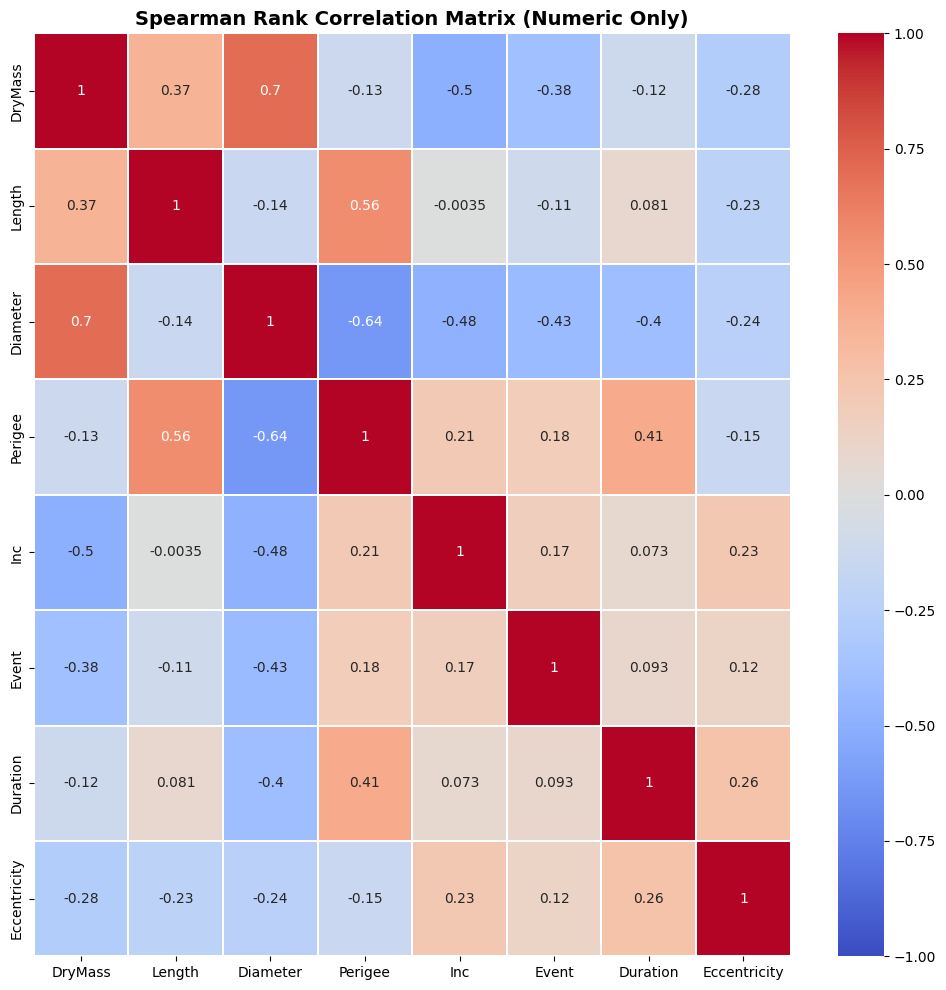

In [ ]:
plt.figure(figsize=(10, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.1,
    vmax=1,
    vmin=-1,
    center=0
)

plt.title('Spearman Rank Correlation Matrix (Numeric Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### VIF

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only NUMERIC columns, as VIF cannot handle strings and dates
X_numeric = df_clean.select_dtypes(include=[np.number]).copy()

# 2. Drop targets (survival data) and features we decided to exclude
drop_cols = ['Duration', 'Event']
X_for_vif = X_numeric.drop(columns=drop_cols, errors='ignore')

# 3. Clean rows from NaN, as linear regression within VIF will not work with missing values
X_for_vif = X_for_vif.dropna()

# 4. Add a constant (intercept) — this is a strict requirement for VIF mathematics
X_vif_with_const = sm.add_constant(X_for_vif)

# 5. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_with_const.values, i)
    for i in range(len(X_vif_with_const.columns))
]

# Remove the constant row from the final output so it doesn't confuse (it always has a high VIF)
vif_data = vif_data[vif_data["feature"] != "const"].reset_index(drop=True)

print("\nMulticollinearity (VIF) analysis for the cleaned model:\n")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))


Multicollinearity (VIF) analysis for the cleaned model:

     feature      VIF
      Length 3.504569
     DryMass 2.868822
     Perigee 2.572775
         Inc 2.163069
    Diameter 1.944003
Eccentricity 1.150608


### Cramer

=== Categorical Feature Association Matrix (Cramer's V) ===
               Owner  Manufacturer   State  Agency     Bus  Launch_Site
Owner         1.0000        0.8259  0.9559  0.6560  0.6545       0.6580
Manufacturer  0.8259        1.0000  0.7092  0.6123  0.6040       0.6522
State         0.9559        0.7092  1.0000  0.2870  0.5124       0.3580
Agency        0.6560        0.6123  0.2870  1.0000  0.6281       0.7663
Bus           0.6545        0.6040  0.5124  0.6281  1.0000       0.6712
Launch_Site   0.6580        0.6522  0.3580  0.7663  0.6712       1.0000


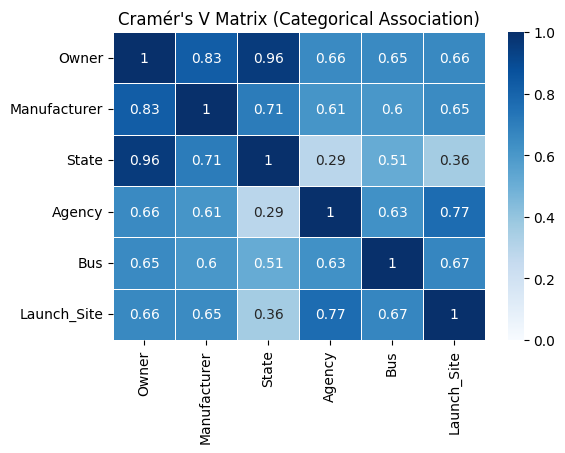

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ Calculates Cramer's V coefficient between two categorical features """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Bias correction for small samples
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# List of your categorical columns (specify exact names from your df_clean)
cat_features = ['Owner', 'Manufacturer', 'State', 'Agency', 'Bus', 'Launch_Site']

# Build the association matrix
v_matrix = pd.DataFrame(index=cat_features, columns=cat_features, dtype=float)

for col1 in cat_features:
    for col2 in cat_features:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1.0
        else:
            v_matrix.loc[col1, col2] = cramers_v(df_clean[col1], df_clean[col2])

print("=== Categorical Feature Association Matrix (Cramer's V) ===")
print(v_matrix.round(4))

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(v_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, linewidths=0.5)
plt.title('Cramér\'s V Matrix (Categorical Association)')
plt.show()

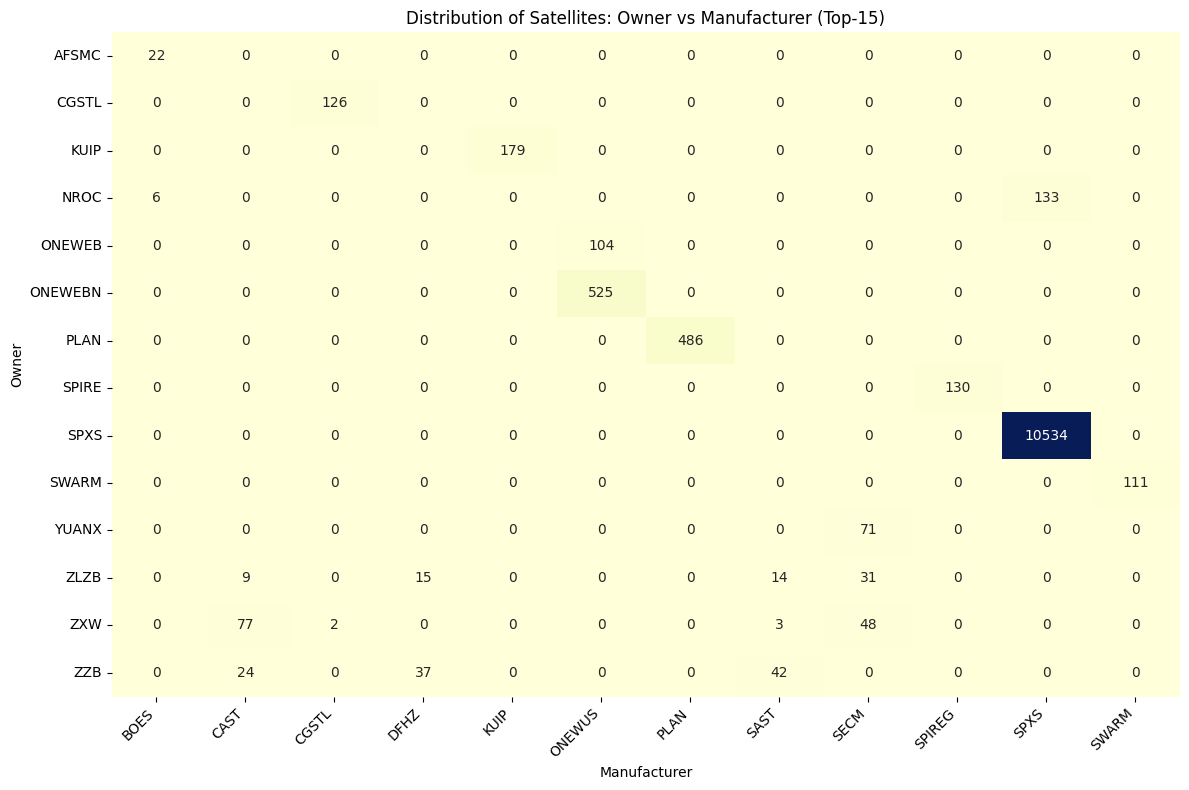

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build a contingency table between Owner and Manufacturer
# Take, for example, the top-15 largest to avoid overloading the chart
top_owners = df_clean['Owner'].value_counts().nlargest(15).index
top_manufacturers = df_clean['Manufacturer'].value_counts().nlargest(15).index

filtered_df = df_clean[df_clean['Owner'].isin(top_owners) & df_clean['Manufacturer'].isin(top_manufacturers)]

ct = pd.crosstab(filtered_df['Owner'], filtered_df['Manufacturer'])

plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Distribution of Satellites: Owner vs Manufacturer (Top-15)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Space Weather Data as a feature (IGNORE)

In [ ]:
filepath1 = '/content/drive/MyDrive/Space/SpaceWeather/MachineLearning/WeatherSatellite.csv'

space_weather=pd.read_csv(filepath1)

In [ ]:
space_weather['time'] = pd.to_datetime(space_weather['time'], errors='coerce')
space_weather.describe()

,time,sym_h
count,1401984,1.401984e+06
mean,2019-08-31 23:57:29.999997952,-1.161401e+01
min,2013-01-01 00:00:00,-4.970000e+02
25%,2016-05-01 23:58:45,-1.900000e+01
50%,2019-08-31 23:57:30,-8.000000e+00
75%,2022-12-30 23:56:15,-1.000000e+00
max,2026-04-30 23:55:00,8.600000e+01
std,NaN,1.862468e+01


In [ ]:
import pandas as pd
import numpy as np

# 1. Format dates in the main dataset (remove time zones if present)
df_clean['LDate'] = pd.to_datetime(df_clean['LDate'], errors='coerce').dt.tz_localize(None)
df_clean['Duration'] = pd.to_numeric(df_clean['Duration'], errors='coerce')

# 2. Format the weather index (ensure it's a DatetimeIndex without time zones)
if 'time' in space_weather.columns:
    space_weather = space_weather.set_index(pd.to_datetime(space_weather['time']))
else:
    space_weather.index = pd.to_datetime(space_weather.index)

space_weather.index = space_weather.index.tz_localize(None)
space_weather = space_weather.sort_index()

# Extract arrays into numpy for significant acceleration (avoids issues with .loc)
omni_times = space_weather.index.values
omni_vals = space_weather['sym_h'].values

NameError: name 'space_weather' is not defined

In [ ]:
def extract_magnetic_features_fixed_window(row, days_window=60):
    launch = row['LDate']
    duration = row['Duration']

    if pd.isna(launch) or pd.isna(duration):
        return pd.Series([np.nan, np.nan], index=['SYM_Min_Peak', 'SYM_Storm_Percent'])

    # Limit the analysis window: either the first N days or the actual life if shorter
    analysis_duration = min(duration, days_window)
    end = launch + pd.to_timedelta(analysis_duration, unit='D')

    launch_np = np.datetime64(launch)
    end_np = np.datetime64(end)

    # Filter the numpy array
    mask = (omni_times >= launch_np) & (omni_times <= end_np)
    satellite_weather_vals = omni_vals[mask]

    if len(satellite_weather_vals) == 0:
        return pd.Series([0.0, 0.0], index=['SYM_Min_Peak', 'SYM_Storm_Percent'])

    # Calculate metrics strictly within the fixed starting window
    min_peak = np.min(satellite_weather_vals)
    storm_minutes = np.sum(satellite_weather_vals <= -100)
    total_minutes = len(satellite_weather_vals)
    storm_percent = (storm_minutes / total_minutes) * 100

    return pd.Series([float(min_peak), float(storm_percent)], index=['SYM_Min_Peak', 'SYM_Storm_Percent'])

# Apply (e.g., take 60 days — critical period for orbit stabilization)
df_clean[['SYM_Min_Peak', 'SYM_Storm_Percent']] = df_clean.apply(
    lambda r: extract_magnetic_features_fixed_window(r, days_window=60),
    axis=1,
    result_type='expand'
)

NameError: name 'omni_times' is not defined

In [ ]:
print("\nChecking calculation results:")
print(df_clean[['SYM_Min_Peak_Fixed', 'SYM_Storm_Percent_Fixed']].describe())


Checking calculation results:


KeyError: "None of [Index(['SYM_Min_Peak_Fixed', 'SYM_Storm_Percent_Fixed'], dtype='object')] are in the [columns]"

In [ ]:
df_clean[(df_clean['LDate']>='2026-01-01')&(df_clean['SYM_Min_Peak']<100)].sort_values('SYM_Storm_Percent', ascending=False)

,#JCAT,Satcat,Launch_Tag,Piece,Type,Name,PLName,LDate,Parent,SDate,...,LV_Type,DDate1,Event,Duration,MassClass,Eccentricity,SYM_Min_Peak_Fixed,SYM_Storm_Percent_Fixed,SYM_Min_Peak,SYM_Storm_Percent
17896,S67304,67304,2026-001,2026-001A,P,CSG FM3,COSMO-Skymed Second Gen FM3,2026-01-03,A11728,2026 Jan 3 0222:16,...,Falcon 9,NaN,0,139.0,Large (>1000kg),0.000357,-251.0,2.951218,-251.0,2.951218
18106,S67529,67529,2026-013,2026-013H,P O,WHDW 19-08,Xingwang Digui 19-08,2026-01-19,S67531,2026 Jan 19 0813?,...,Chang Zheng 12,NaN,0,123.0,Small (100-1000kg),0.000893,-251.0,2.951218,-251.0,2.951218
18107,S67530,67530,2026-013,2026-013J,P O,WHDW 19-09,Xingwang Digui 19-09,2026-01-19,S67531,2026 Jan 19 0813?,...,Chang Zheng 12,NaN,0,123.0,Small (100-1000kg),0.000825,-251.0,2.951218,-251.0,2.951218
18090,S67513,67513,2026-012,2026-012W,P O,Starlink 36531,Starlink Group 6-100-21,2026-01-18,A11737,2026 Jan 19 0036:44,...,Falcon 9,NaN,0,124.0,Small (100-1000kg),0.000754,-251.0,2.951218,-251.0,2.951218
18091,S67514,67514,2026-012,2026-012X,P O,Starlink 36530,Starlink Group 6-100-22,2026-01-18,A11737,2026 Jan 19 0036:44,...,Falcon 9,NaN,0,124.0,Small (100-1000kg),0.000754,-251.0,2.951218,-251.0,2.951218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18965,S69011,NNA,2026-100,2026-100AH,P ?,Helios,Helios,2026-05-03,A11839,2026 May 3 0759:54,...,Falcon 9,NaN,0,19.0,Nano (0-10kg),0.000581,0.0,0.000000,0.0,0.000000
18966,S69012,69012,2026-100,2026-100AJ,P,Jackal AOV,Jackal AOV,2026-05-03,A11839,2026 May 3 0759:54,...,Falcon 9,NaN,0,19.0,Small (100-1000kg),0.000799,0.0,0.000000,0.0,0.000000
18967,S69013,69013,2026-100,2026-100AK,P,CAS500-2,NEXTSAT-2,2026-05-03,A11839,2026 May 3 0759:54,...,Falcon 9,NaN,0,19.0,Small (100-1000kg),0.000508,0.0,0.000000,0.0,0.000000
18968,S69014,NNA,2026-100,2026-100AL,P ?,Lynk Tower 8,Lynk Tower 8,2026-05-03,A11839,2026 May 3 0759:54,...,Falcon 9,NaN,0,19.0,Micro (10-100kg),0.000581,0.0,0.000000,0.0,0.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate correlation matrices
# Spearman is critically important here, as the relationship may not be strictly linear
pearson_corr = df_clean[['SYM_Min_Peak', 'SYM_Storm_Percent']].corr(method='pearson').iloc[0, 1]
spearman_corr = df_clean[['SYM_Min_Peak', 'SYM_Storm_Percent']].corr(method='spearman').iloc[0, 1]

print("=== CORRELATION ANALYSIS RESULTS ===")
print(f"Pearson linear correlation (Pearson r):  {pearson_corr:.4f}")
print(f"Spearman rank correlation (Spearman rho): {spearman_corr:.4f}")

# 2. Visualize the dependency
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

# Plot a scatter plot with a logarithmic scale to see the structure
# of both CubeSats (small values) and geostationary giants (large values)
sns.scatterplot(
    data=df_clean,
    x='SYM_Min_Peak',
    y='SYM_Storm_Percent',
    alpha=0.4,
    color='slateblue',
    edgecolor='none',
    ax=ax
)

# Formatting
ax.set_title(f"SYM_Min_Peak", fontsize=13, fontweight='bold')
ax.set_xlabel("SYM_Min_Peak", fontsize=11)
ax.set_ylabel("SYM_Storm_Percent", fontsize=11)
ax.legend()

plt.tight_layout()
plt.show()

KeyError: "None of [Index(['SYM_Min_Peak', 'SYM_Storm_Percent'], dtype='object')] are in the [columns]"

# Feature Engineering

**1. Target variables**. These two columns are passed to the model as a pair (Event, Duration):

* Duration — satellite lifetime in days (continuous time axis).
* Event — status (1 — deorbited/broken, 0 — alive/censored).

**2. Quantitative features.** RSF finds non-linear dependencies and threshold values in them.

* Perigee / Apogee / Inc (Perigee, Apogee, Inclination) — the absolute top 1 in importance. This is pure orbital physics, determining atmospheric and radiation effects.

* OrbPay (Payload mass) or Final_Mass / DryMass / Mass / TotMass — choose one or two of the most populated columns with mass (highly correlated, choose DryMass and OrbPay).

* Length / Diameter / Span — geometric dimensions. Proxies for 'sail area' and apparatus size.

**3. Categorical features (Factors)** In Python (scikit-survival) these will need to be converted to numbers via pd.get_dummies().

* Category (Mission type: Sat LEO, Sat GEO, etc.) — a crucial marker of operating conditions.

* OpOrbit (Operating orbit) — a companion to precise perigee/apogee numbers.

* Agency / Owner / State — who operates and which country. Choose one, maximum two, otherwise they will duplicate each other.

* LV_Type (Launch Vehicle) — reliability and launch accuracy.

* Launch_Site (Cosmodrome) — geographical marker.

* Manufacturer / Bus (Manufacturer / Space Platform) — an indicator of 'hardware' reliability.

* Shape (Apparatus shape: Box, Cyl) — affects aerodynamics in the upper atmosphere.

**4. What needs to be REMOVED (Not features for RSF)**
These columns are either unique IDs, duplicate target variables, or contain garbage flags:

Unique text IDs (will lead to overfitting): '**#JCAT', Satcat, Launch_Tag, Piece, Name, PLName, Parent, AltNames**.

Dates (the model cannot work with dates directly): **LDate, SDate, ODate, DDate1.** (From LDate, if desired, only the launch year can be extracted as a number).

Data quality flags (usually text characters or emptiness): MassFlag, DryFlag, TotFlag, LFlag, DFlag, SpanFlag, Apoflag, RangeFlag, OQUAL.

Technical statuses and error codes: Status, Dest, Motor (too many unique engine types), FailCode, LaunchCode (if rocket accidents are filtered, all will have OS, i.e., zero variance).

In [ ]:
df_clean.columns

Index(['#JCAT', 'Satcat', 'Launch_Tag', 'Piece', 'Type', 'Name', 'PLName',
       'LDate', 'Parent', 'SDate', 'Primary', 'Status', 'Owner', 'State',
       'Manufacturer', 'Bus', 'DryMass', 'Length', 'Diameter', 'Shape',
       'ODate', 'Perigee', 'Inc', 'OpOrbit', 'Agency', 'LaunchCode',
       'Category', 'Launch_Site', 'Launch_Pad', 'LV_Type', 'DDate1', 'Event',
       'Duration', 'MassClass', 'Eccentricity'],
      dtype='object')

In [ ]:
df_clean.shape

(18987, 35)

In [ ]:
columns_to_drop=['#JCAT', 'Satcat', 'Launch_Tag', 'Piece', 'Type', 'PLName', 'Parent', 'SDate','ODate', 'LaunchCode','DDate1', 'MassClass']
dataset=df_clean.drop(columns_to_drop,axis=1)
dataset['LDate'] = pd.to_datetime(dataset['LDate'])
dataset['Year']=dataset['LDate'].dt.year
dataset.shape

(18987, 24)

In [ ]:
dataset.head().T

,0,1,2,3,4
Name,Skynet 4A,JCSAT 2,Leasat 5,Kosmos-2056,SPOT 2
LDate,1990-01-01 00:00:00,1990-01-01 00:00:00,1990-01-09 00:00:00,1990-01-18 00:00:00,1990-01-22 00:00:00
Primary,Earth,Earth,Earth,Earth,Earth
Status,N,O,N,O,O
Owner,MOD,JCSAT,HCI,UNKS,CNES
State,UK,J,US,SU,F
Manufacturer,BAES,HSES,HSES,NPOPM,MMST
Bus,ECS,HS-393,HS-381,Strela-2M,SPOT
DryMass,615.0,1100.0,1230.0,800.0,1750.0
Length,2.1,10.0,4.0,3.0,4.5


In [ ]:
for col in dataset.select_dtypes(include=['object']).columns:
    dataset[col] = dataset[col].astype(str).str.strip()

In [ ]:
# Let's write a loop that neatly displays information for each column
for col in dataset.columns:
    print(f"\n=========================================")
    print(f" COLUMN: {col} | Type: {dataset[col].dtype}")
    print(f" Missing values (NaN): {dataset[col].isna().sum()} ({dataset[col].isna().mean()*100:.1f} %)")
    print(f" Total unique values: {dataset[col].nunique()}")
    print(f"=========================================")

    # If the column is numeric and has too many unique values (e.g., Perigee or Mass)
    if dataset[col].dtype in ['int64', 'float64'] and dataset[col].nunique() > 10:
        # For numbers, it's better to show the general distribution instead of a long value_counts list
        print(dataset[col].describe()[['mean', 'min', '50%', 'max']].to_string())
    else:
        # For categories, display the top-30 most frequent values (to avoid overwhelming the screen)
        print(dataset[col].value_counts(dropna=False).head(30))


 COLUMN: Name | Type: object
 Missing values (NaN): 0 (0.0 %)
 Total unique values: 18887
Name
Molniya-3                       16
Xingwang Jishu Shiyan W.        15
Gorizont                        13
Molniya-1                       10
Raduga                           9
Molniya-1T                       7
Raduga-1                         7
Nadezhda                         4
Cartosat-2 Series Satellite      4
Meteor-2                         3
Raduga-1M                        3
Digui Tongxin Shiyan Wei.        3
Meteor-3                         3
Luch                             2
COMPASS-2                        2
Harbinger                        2
Skykraft 4A                      2
Daqi Huanjing Jiance Weixing     2
MisrSat-2                        2
Stella                           2
Cora                             2
Ekran-M                          2
Okean                            2
Hitomi                           2
Resurs-O1                        2
Tsubame                      

In [ ]:
# Drop columns
dataset=dataset.drop(['Primary','Status','Launch_Pad','LV_Type', 'Category', 'Agency'], axis=1)

In [ ]:
# NaN in OpOrbit
dataset['OpOrbit'] = dataset['OpOrbit'].fillna('Unknown')

## Aggregating data

In [ ]:
import pandas as pd

def clean_satellite_shape_(shape_str):
    if pd.isna(shape_str):
        return 'Unknown'

    # Convert to lowercase and remove extra spaces, question marks
    s = str(shape_str).lower().replace(' ', '').replace('?', '')

    # Group by key geometry types
    if 'box+' in s or 'box' in s:
        if 'pan' in s or 'panel' in s:
            return 'Box_with_Panels'
        elif 'ant' in s or 'dish' in s:
            return 'Box_with_Antennas'
        else:
            return 'Pure_Box'

    elif 'cyl' in s:
        if 'pan' in s:
            return 'Cylinder_with_Panels'
        else:
            return 'Pure_Cylinder'

    elif 'sphere' in s:
        return 'Sphere'

    elif 'trapezoid' in s or 'prism' in s:
        return 'Complex_Prism_with_Panels'

    return 'Other'

# Apply cleaning and create a nicely ordered feature
dataset['Clean_Shape'] = dataset['Shape'].apply(clean_satellite_shape_)

# See the result
print(dataset['Clean_Shape'].value_counts())

Clean_Shape
Box_with_Panels              14806
Pure_Box                      1900
Complex_Prism_with_Panels      747
Cylinder_with_Panels           553
Pure_Cylinder                  392
Box_with_Antennas              353
Sphere                         118
Other                          118
Name: count, dtype: int64


In [ ]:
import re

def clean_satellite_bus(bus_str):
    if pd.isna(bus_str):
        return 'Unknown'

    b = str(bus_str).strip().lower()

    # 1. Group all Starlinks (including Starshield) into one class
    if 'starlink' in b or 'starshield' in b:
        return 'Starlink_Platform'

    # 2. Standardize Cubesats by their units (U)
    if 'cubesat' in b:
        match = re.search(r'(\d+\.?\d*)u', b)
        if match:
            return f'Cubesat_{match.group(1)}U'
        return 'Cubesat_Other'

    # 3. Highlight other major mega-constellations
    if 'arrow' in b: # Platform for OneWeb
        return 'Arrow_Platform'
    if 'kuiper' in b:
        return 'Kuiper_Platform'

    # Group all other 1000+ rare platforms
    return 'Other_Platform'

# Apply the cleaning function
dataset['Clean_Bus'] = dataset['Bus'].apply(clean_satellite_bus)

# Display the clean and compact result
print(dataset['Clean_Bus'].value_counts())

Clean_Bus
Starlink_Platform    10671
Other_Platform        5091
Cubesat_3U            1181
Arrow_Platform         664
Cubesat_6U             417
Cubesat_1U             222
Cubesat_0.25U          207
Kuiper_Platform        179
Cubesat_2U              68
Cubesat_1.5U            66
Cubesat_16U             66
Cubesat_12U             65
Cubesat_8U              30
Cubesat_0.5U            19
Cubesat_0.3U            19
Cubesat_4U              11
Cubesat_Other           10
Cubesat_27U              1
Name: count, dtype: int64


In [ ]:
def clean_satellite_owner(owner_str):
    if pd.isna(owner_str):
        return 'Unknown'

    # Convert to uppercase and remove extra spaces
    owner = str(owner_str).strip().upper()

    # List of main players we want to keep as is
    # Combine OneWeb into one class
    if owner in ['ONEWEBN', 'ONEWEB']:
        return 'ONEWEB'

    main_owners = [
        'SPXS',     # SpaceX (Starlink)
        'PLAN',     # Planet Labs
        'NROC',     # NRO (US Intelligence)
        'ZXW',      # China Satellite Network Group (Chinese Starlink)
        'KUIP',     # Project Kuiper (Amazon)
        'CGSTL',    # Chang Guang (Chinese commercial Earth observation)
        'SPIRE',    # Spire Global
        'ZZB',      # China Strategic Support Force (Chinese Military)
        'SWARM',    # Swarm Technologies (Internet of Things)
        'PVO',      # Russian Aerospace Forces (in historical records)
        'YUANX',    # Chinese experimental series
        'ZLZB',     # Chinese intelligence agencies
        'AFSMC',    # US Air Force Space Command (now Space Force)
        'ISRO',     # Indian Space Agency
        'CNSA',     # China National Space Administration
        'VKS',      # Russian Aerospace Forces
        'CASC',     # China Aerospace Science and Technology Corporation
        'IRIDS'     # Iridium (Famous satellite communication network)
    ]

    if owner in main_owners:
        return owner

    # All other 1500 small operators are sent to "Others"
    return 'Other_Owners'

# Create a new cleaned column
dataset['Clean_Owner'] = dataset['Owner'].apply(clean_satellite_owner)

# Check how compact and neat the list has become
print(dataset['Clean_Owner'].value_counts())

Clean_Owner
SPXS            10534
Other_Owners     5502
ONEWEB            635
PLAN              486
NROC              192
ZXW               184
KUIP              179
CGSTL             146
SPIRE             131
ZZB               113
SWARM             111
PVO               108
YUANX             102
AFSMC              87
ZLZB               87
ISRO               85
CNSA               83
VKS                77
CASC               75
IRIDS              70
Name: count, dtype: int64


In [ ]:
def clean_satellite_manufacturer(man_str):
    if pd.isna(man_str):
        return 'Unknown'

    # Convert to uppercase, remove spaces and question marks
    m = str(man_str).strip().upper().replace('?', '')

    # Merge obvious duplicates of mega-constellation manufacturers
    if m.startswith('SWARM'):
        return 'SWARM'
    if m == 'ONEWUS':
        return 'ONEWEB_US' # Joint factory of OneWeb and Airbus in the USA
    if m == 'SPIREG':
        return 'SPIRE'

    # Top manufacturers of space technology (USA, Europe, China, Russia, India)
    main_manufacturers = [
        'SPXS',   # SpaceX
        'PLAN',   # Planet Labs
        'CAST',   # China Academy of Space Technology (Main manufacturer of China)
        'CGSTL',  # Chang Guang (China)
        'SECM',   # Chinese defense factories
        'KUIP',   # Amazon Kuiper
        'DFHZ',   # DFH Satellite Co (China)
        'RESH',   # JSC "Reshetnev" (Information Satellite Systems, Russia)
        'LOR',    # Loral Space & Communications
        'NPOPM',  # NPO of Applied Mechanics (historical name of Reshetnev)
        'SAST',   # Shanghai Academy of Spaceflight Technology
        'BOES',   # Boeing Space & Intelligence Systems
        'NPOPMR', # Another modification of NPO PM / Reshetnev records
        'SPUT',   # Sputnix (Russian private cubesat manufacturer)
        'POL',    # Polytechnic Institutes / Universities of China
        'HSES',   # Harbin Institute of Technology (China)
        'UTIAS',  # University of Toronto (Canada)
        'GWCG',   # China Satellite Network Group
        'ICEYE',  # Finnish ICEYE radar satellites
        'THALES', # Thales Alenia Space (Europe)
        'URUGUS', # Satellogic (Argentina/USA)
        'YUZH',   # Ukraine
        'DFHS',   # Dongfanghong Projects
        'ADST',   # Advanced Satellite Technology
        'OATKGA'  # Orbital ATK / Northrop Grumman
    ]

    if m in main_manufacturers:
        return m

    # All other small manufacturers are sent to one category
    return 'OTHER_MANUFACTURERS'

In [ ]:
# 1. Find the list of the 30 most frequent countries in the dataset
top_30_states = dataset['State'].value_counts().head(30).index.tolist()

# 2. Create a function that keeps the country if it's in the top 30, otherwise writes 'OTHERS'
def clean_satellite_state_top30(state_str):
    if pd.isna(state_str):
        return 'Unknown'

    s = str(state_str).strip().upper()

    if s in top_30_states:
        return s

    return 'OTHERS'

In [ ]:
dataset.columns

Index(['Name', 'LDate', 'Owner', 'State', 'Manufacturer', 'Bus', 'DryMass',
       'Length', 'Diameter', 'Shape', 'Perigee', 'Inc', 'OpOrbit',
       'Launch_Site', 'Event', 'Duration', 'Eccentricity', 'Year',
       'Clean_Shape', 'Clean_Bus', 'Clean_Owner'],
      dtype='object')

In [ ]:
dataset=dataset.drop(['Owner','Bus','Shape'], axis=1)

In [ ]:
dataset = dataset.rename(columns={'Clean_Owner': 'Owner', 'Clean_Bus': 'Bus', 'Clean_Shape': 'Shape'})

In [ ]:
dataset.head(10).T

,0,1,2,3,4,5,6,7,8,9
Name,Skynet 4A,JCSAT 2,Leasat 5,Kosmos-2056,SPOT 2,UoSAT-OSCAR-14,UoSAT-OSCAR-15,AMSAT-OSCAR-16,DOVE-OSCAR-17,WEBERSAT-OSCAR-18
LDate,1990-01-01 00:00:00,1990-01-01 00:00:00,1990-01-09 00:00:00,1990-01-18 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00
State,UK,J,US,SU,F,UK,UK,US,BR,US
Manufacturer,BAES,HSES,HSES,NPOPM,MMST,SSTL,SSTL,AMNA,WEB/AMNA,WEB/AMNA
DryMass,615.0,1100.0,1230.0,800.0,1750.0,46.0,47.0,10.0,12.0,12.0
Length,2.1,10.0,4.0,3.0,4.5,0.7,0.6,0.2,0.2,0.3
Diameter,1.9,3.6,4.3,2.0,2.0,0.4,0.4,0.2,0.2,0.2
Perigee,35449,35776,35264,775,824,786,786,787,787,788
Inc,3.37,0.26,3.36,74.04,98.72,98.71,98.71,98.72,98.72,98.71
OpOrbit,GEO/ID,GEO/S,GEO/I,LEO/I,LEO/S,LEO/S,LEO/S,LEO/S,LEO/S,LEO/S


In [ ]:
# Let's see what your elongated orbits look like now
dataset.sort_values('Eccentricity', ascending=False).head(100)

,Name,LDate,State,Manufacturer,DryMass,Length,Diameter,Perigee,Inc,OpOrbit,Launch_Site,Event,Duration,Eccentricity,Year,Shape,Bus,Owner
2115,SES-8,2013-12-03,UK,OSCD,1500.0,4.3,2.3,395,20.51,VHEO,CC,0,4553.0,0.853517,2013,Box_with_Panels,Other_Platform,Other_Owners
1233,Tan Ce 1,2003-12-29,CN,DFH,350.0,2.1,1.4,555,28.50,VHEO,XSC,1,1385.0,0.848228,2003,Pure_Cylinder,Other_Platform,CASC
5980,Turksat 5B,2021-12-19,TR,ADSB,3500.0,4.5,3.0,198,27.12,HEO,CC,0,1615.0,0.839382,2021,Box_with_Panels,Other_Platform,Other_Owners
2729,Inmarsat 5F4,2017-05-15,UK,BOES,3700.0,7.0,3.2,384,24.52,GEO/NS,KSC,0,3294.0,0.837563,2017,Box_with_Panels,Other_Platform,Other_Owners
12206,Turksat 6A,2024-07-08,TR,TUSAS,1700.0,4.5,3.0,383,24.10,GEO/NS,CC,0,683.0,0.836564,2024,Box_with_Panels,Other_Platform,Other_Owners
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,Molniya-1,1992-08-06,RU,NPOPM,1620.0,4.4,1.4,661,62.87,HEO/M,NIIP-53,1,5720.0,0.734920,1992,Cylinder_with_Panels,Other_Platform,Other_Owners
1034,STRV 1c,2000-11-16,UK,DERA,95.0,0.7,0.7,609,6.43,GTO,CSG,0,9318.0,0.734433,2000,Pure_Box,Other_Platform,Other_Owners
1033,AMSAT-OSCAR-40,2000-11-16,D,AMDL,397.0,0.7,2.2,613,6.42,GTO,CSG,0,9318.0,0.734412,2000,Cylinder_with_Panels,Other_Platform,Other_Owners
1035,STRV 1d,2000-11-16,UK,DERA,95.0,0.7,0.7,613,6.42,GTO,CSG,0,9318.0,0.734412,2000,Pure_Box,Other_Platform,Other_Owners


Inmarsat 5F4: (ответ почему GEO/NS имеет такую эллиптическую орбиту: цель выйти на GEO)
https://spaceflightnow.com/2017/05/16/fourth-satellite-for-inmarsats-global-broadband-network-launched-by-spacex/

# Kaplan-Meier Estimator

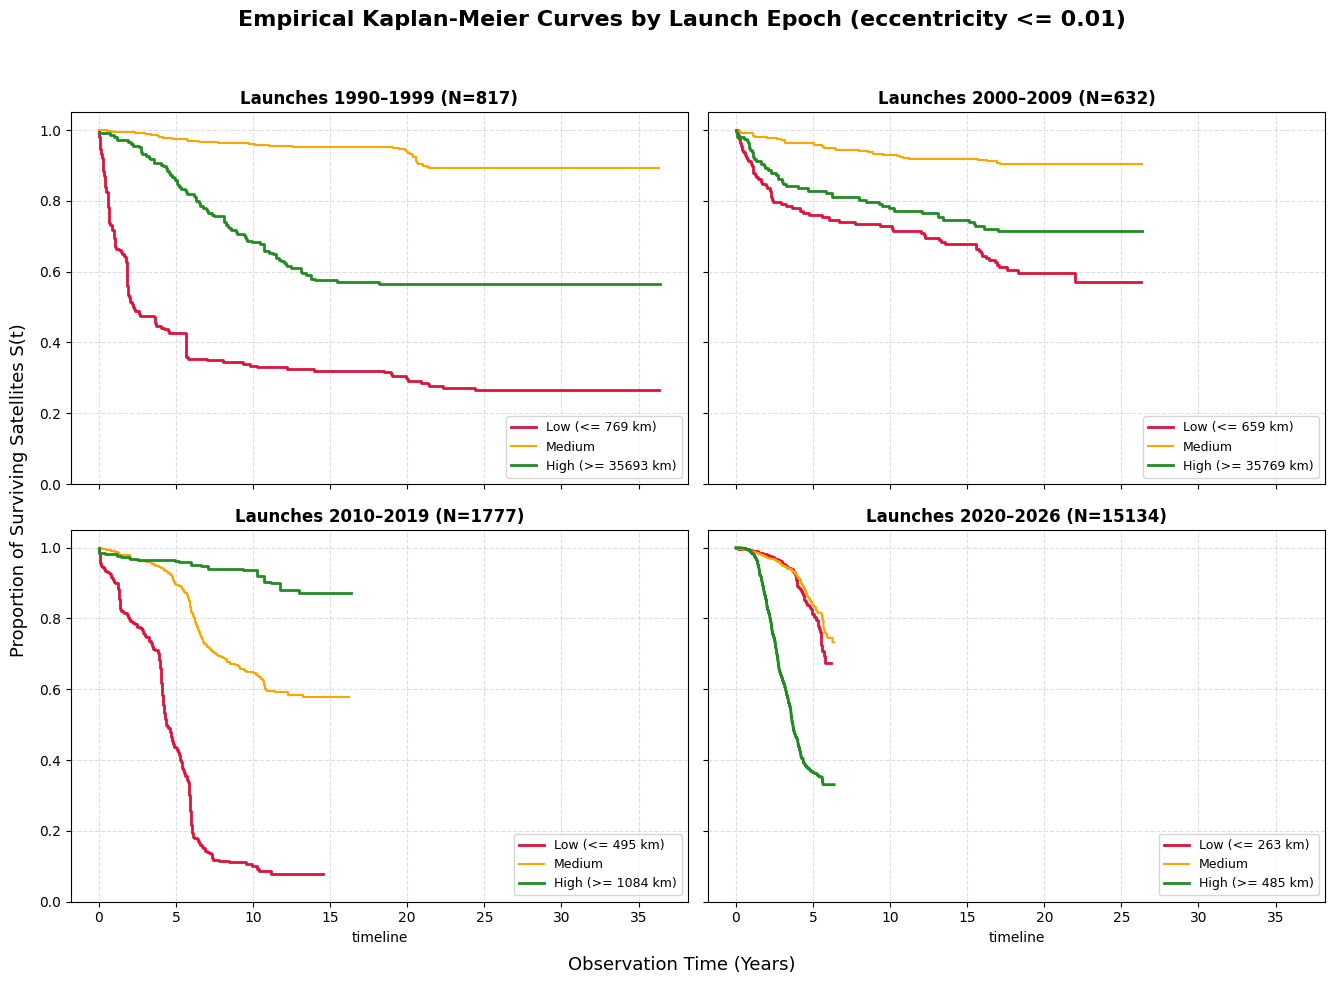

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Prepare data: extract year from LDate and select necessary columns
df_km = df_clean.copy()
df_km['Launch_Year'] = pd.to_datetime(df_km['LDate']).dt.year

# Target column names (from your structured array)
# Replace 'Status' and 'Duration' if they are named differently in df_clean
status_col = 'Event'      # Binary flag (1 - deceased, 0 - alive/censored)
duration_col = 'Duration'  # Life time (X-axis)

# Convert duration from days to years
df_km['Duration_Years'] = df_km[duration_col] / 365.25
duration_col_plot = 'Duration_Years'

# Set up a 2x2 grid for plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Our historical breakdown
epochs = [
    ("1990–1999", 1990, 1999),
    ("2000–2009", 2000, 2009),
    ("2010–2019", 2010, 2019),
    ("2020–2026", 2020, 2026)
]

kmf = KaplanMeierFitter()

for i, (name, start_y, end_y) in enumerate(epochs):
    # Filter the original dataset: epoch + circular orbits
    epoch_mask = (df_km['Launch_Year'] >= start_y) & \
                 (df_km['Launch_Year'] <= end_y) & \
                  (df_km['Eccentricity'] <= 0.01) # Soft filter for historical epochs

    df_epoch = df_km[epoch_mask]

    if len(df_epoch) < 10:
        axes[i].text(0.5, 0.5, f"Not enough data for {name}", ha='center', va='center', fontsize=12)
        axes[i].set_title(f"Epoch: {name}")
        continue

    # Calculate perigee quantiles STRICTLY within the current epoch
    low_val = df_epoch['Perigee'].quantile(0.25)
    high_val = df_epoch['Perigee'].quantile(0.75)

    # Distribute satellites into three height groups
    df_low = df_epoch[df_epoch['Perigee'] <= low_val]
    df_high = df_epoch[df_epoch['Perigee'] >= high_val]
    df_mid = df_epoch[(df_epoch['Perigee'] > low_val) & (df_epoch['Perigee'] < high_val)]

    # Plot Kaplan-Meier curve for LOW perigee
    if len(df_low) > 0:
        kmf.fit(durations=df_low[duration_col_plot], event_observed=df_low[status_col], label=f"Low (<= {low_val:.0f} km)")
        kmf.plot_survival_function(ax=axes[i], ci_show=False, color="crimson", lw=2)

    # For MEDIUM perigee
    if len(df_mid) > 0:
        kmf.fit(durations=df_mid[duration_col_plot], event_observed=df_mid[status_col], label="Medium")
        kmf.plot_survival_function(ax=axes[i], ci_show=False, color="orange", lw=1.5)

    # For HIGH perigee
    if len(df_high) > 0:
        kmf.fit(durations=df_high[duration_col_plot], event_observed=df_high[status_col], label=f"High (>= {high_val:.0f} km)")
        kmf.plot_survival_function(ax=axes[i], ci_show=False, color="forestgreen", lw=2)

    # Subplot formatting
    axes[i].set_title(f"Launches {name} (N={len(df_epoch)})", fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle="--", alpha=0.4)
    axes[i].legend(fontsize=9, loc="lower right")
    axes[i].set_ylim(0, 1.05)

# Overall captions for the entire panel
fig.suptitle("Empirical Kaplan-Meier Curves by Launch Epoch (eccentricity <= 0.01)", fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.02, "Observation Time (Years)", ha='center', fontsize=13)
fig.text(0.02, 0.5, "Proportion of Surviving Satellites S(t)", va='center', rotation='vertical', fontsize=13)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.show()

In [ ]:
recent=dataset[(dataset['Perigee']>=485) & (dataset['Year']>=2020)]
recent.Event.value_counts()

,count
Event,
0,2777
1,1101


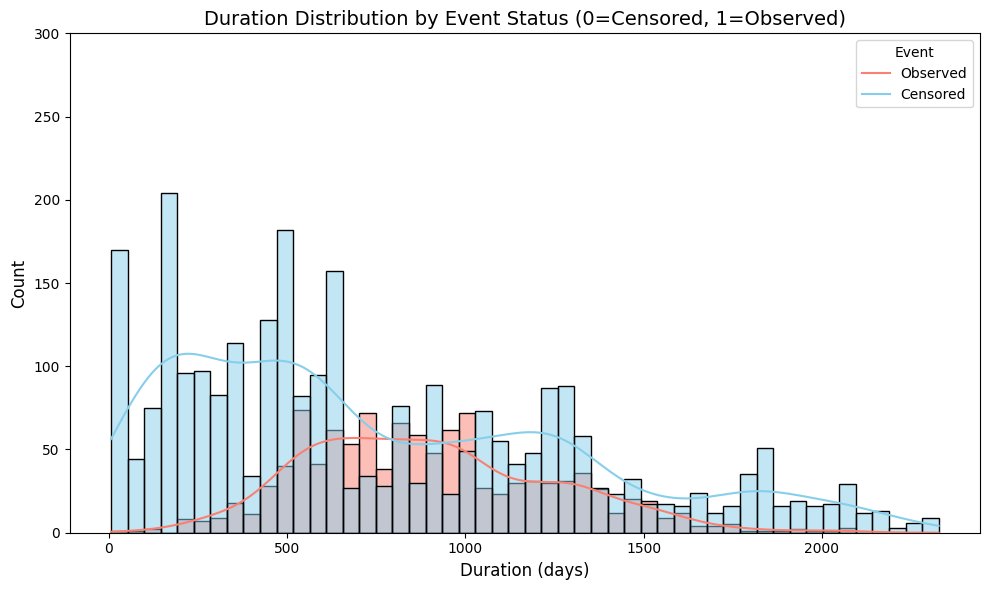

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=recent, x='Duration', hue='Event', bins=50, kde=True, palette={0: 'skyblue', 1: 'salmon'})
plt.title('Duration Distribution by Event Status (0=Censored, 1=Observed)', fontsize=14)
plt.xlabel('Duration (days)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, 300)
plt.legend(title='Event', labels=['Observed', 'Censored'])
plt.tight_layout()
plt.show()

# Random Survival Forests

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# 1. Formulate lists of features

features = [
    'DryMass', #'Length',
    'Perigee', 'Inc', 'Eccentricity', #'Launch_Year',
    'OpOrbit', 'Launch_Site', 'Shape',
    'Bus', 'Owner'
]

# Extract the feature matrix (X)
X = dataset[features].copy()

# 2. One-Hot encoding of categorical variables
# drop_first=True saves from extra collinearity of categories
X_encoded = pd.get_dummies(X, drop_first=True)

# Fill any random NaNs with medians (RSF cannot handle missing values)
X_encoded = X_encoded.fillna(X_encoded.median())

# 3. Prepare the target (y) for scikit-survival specifics
# It needs a structured numpy array with fields (Status, Time)
y = np.array(
    list(zip(dataset['Event'].astype(bool), dataset['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 4. Split into training and testing samples (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("--- Starting RSF training (this may take a few minutes) ---")

# 5. Model initialization and training
# n_estimators=100 - base ensemble of 100 trees
# min_samples_split=10 and min_samples_leaf=5 protect against overfitting on noise

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,        # use all Colab processor cores
    random_state=42
)

rsf.fit(X_train, y_train)

# 6. Model quality evaluation via C-index (Concordance Index)
# 0.5 - random guessing, 1.0 - ideal prediction of death order
train_c_index = rsf.score(X_train, y_train)
test_c_index = rsf.score(X_test, y_test)

print("=================================================")
print(f"C-index on training set (Train): {train_c_index:.4f}")
print(f"C-index on test set (Test):  {test_c_index:.4f}")
print("=================================================")

Training set: (15189, 112)
Test set: (3798, 112)
--- Starting RSF training (this may take a few minutes) ---
C-index on training set (Train): 0.8872
C-index on test set (Test):  0.8718


# Feature Importance (skip)

In [ ]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.6 MB/s eta 0:00:00


## Small subset (400)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import eli5
from eli5.sklearn import PermutationImportance
import numpy as np

# 1. Генерируем случайные порядковые номера строк (от 0 до длины тест-сета)
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=400, replace=False)

# Вытаскиваем подвыборку по позициям (iloc для X, обычный срез для numpy y)
X_test_sub = X_test.iloc[sample_indices]
y_test_sub = y_test[sample_indices]

print("Считаем быстрый Permutation Importance на подвыборке...")

# 2. Запускаем permutation на подвыборке
perm = PermutationImportance(rsf, n_iter=2, random_state=42)
perm.fit(X_test_sub, y_test_sub)

Считаем быстрый Permutation Importance на подвыборке...


,estimator,RandomSurviva...ndom_state=42)
,scoring,None
,n_iter,2
,random_state,42
,cv,'prefit'
,refit,True
,n_estimators,100
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0


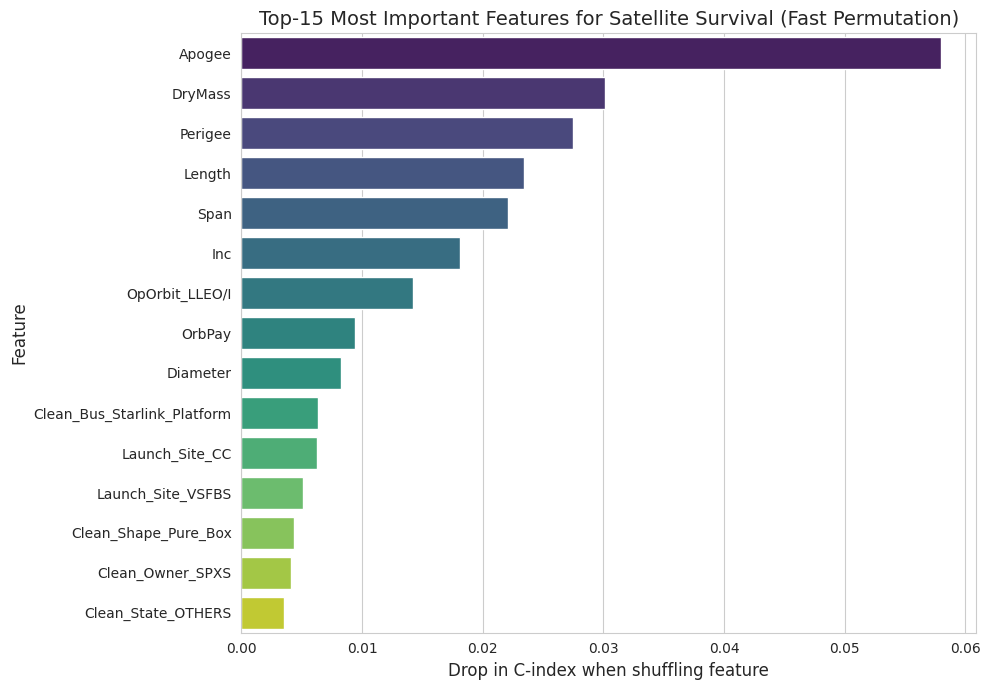

============== TOP-15 FEATURES ===============
                    feature   weight
                     Apogee 0.058015
                    DryMass 0.030103
                    Perigee 0.027502
                     Length 0.023456
                       Span 0.022060
                        Inc 0.018086
             OpOrbit_LLEO/I 0.014185
                     OrbPay 0.009416
                   Diameter 0.008260
Clean_Bus_Starlink_Platform 0.006334
             Launch_Site_CC 0.006261
          Launch_Site_VSFBS 0.005081
       Clean_Shape_Pure_Box 0.004335
           Clean_Owner_SPXS 0.004070
         Clean_State_OTHERS 0.003516


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract weights directly from the perm object
# In eli5, weights are in .results_, but it's simpler to take the averaged .feature_importances_
importances_df = pd.DataFrame({
    'feature': X_test.columns.tolist(),        # Feature names are taken directly from the original dataframe
    'weight': perm.feature_importances_        # Weights are from the calculated object
})

# 2. Sort by decreasing weight and take strictly the TOP-15
top_fi = importances_df.sort_values(by='weight', ascending=False).head(15)

# 3. Plot the graph
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

sns.barplot(
    x="weight",
    y="feature",
    data=top_fi,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title('Top-15 Most Important Features for Satellite Survival (Fast Permutation)', fontsize=14)
plt.xlabel('Drop in C-index when shuffling feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print exact numbers as text
print("============== TOP-15 FEATURES ===============")
print(top_fi.to_string(index=False))

## Subset (2500)

Fields defined in target: status = 'Status', time = 'Time'
Running step-by-step Permutation Importance on a sample of 2500 rows...
Base C-index of the model on the subsample: 0.8885

Progress: [10/174] features processed... Current: OpOrbit_GEO/ID
Progress: [20/174] features processed... Current: OpOrbit_LEO/R
Progress: [30/174] features processed... Current: OpOrbit_nan
Progress: [40/174] features processed... Current: Launch_Site_HCSLS
Progress: [50/174] features processed... Current: Launch_Site_MARS
Progress: [60/174] features processed... Current: Launch_Site_SPFLA
Progress: [70/174] features processed... Current: Launch_Site_WIMB
Progress: [80/174] features processed... Current: Clean_Shape_Sphere
Progress: [90/174] features processed... Current: Clean_Bus_Cubesat_3U
Progress: [100/174] features processed... Current: Clean_Owner_CNSA
Progress: [110/174] features processed... Current: Clean_Owner_SPXS
Progress: [120/174] features processed... Current: Clean_Manufacturer_DFHS
Progr

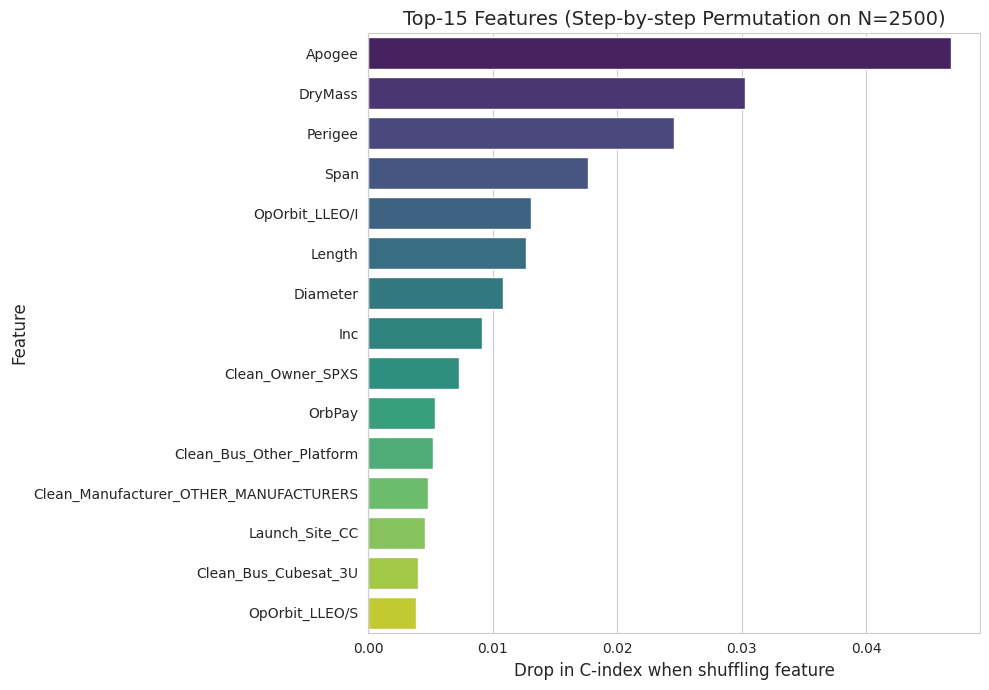


============== TOP-15 FEATURES ===============
                               feature   weight
                                Apogee 0.046819
                               DryMass 0.030237
                               Perigee 0.024560
                                  Span 0.017630
                        OpOrbit_LLEO/I 0.013074
                                Length 0.012633
                              Diameter 0.010779
                                   Inc 0.009140
                      Clean_Owner_SPXS 0.007285
                                OrbPay 0.005388
              Clean_Bus_Other_Platform 0.005189
Clean_Manufacturer_OTHER_MANUFACTURERS 0.004762
                        Launch_Site_CC 0.004539
                  Clean_Bus_Cubesat_3U 0.003970
                        OpOrbit_LLEO/S 0.003798


In [ ]:
import numpy as np
import pandas as pd
from sksurv.metrics import concordance_index_censored
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Automatically determine field names in your structured array y
status_field, duration_field = y_test.dtype.names
print(f"Fields defined in target: status = '{status_field}', time = '{duration_field}'")

# 2. Increase sample to 2500 rows for monolithic statistics
sample_size = min(2500, len(X_test))

np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=sample_size, replace=False)

X_sub = X_test.iloc[sample_indices].copy()
y_sub = y_test[sample_indices]

print(f"Running step-by-step Permutation Importance on a sample of {sample_size} rows...")

# 3. Calculate the base C-index of the model on the subsample
base_preds = rsf.predict(X_sub)
base_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], base_preds)[0]
print(f"Base C-index of the model on the subsample: {base_cindex:.4f}\n")

# 4. Run step-by-step feature traversal with logging
importances = {}
features = X_sub.columns.tolist()
total_features = len(features)

for idx, col in enumerate(features, 1):
    original_col = X_sub[col].copy()

    # Shuffle the feature
    X_sub[col] = np.random.permutation(X_sub[col].values)

    # Calculate score with the broken feature
    shuffled_preds = rsf.predict(X_sub)
    new_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], shuffled_preds)[0]

    # Calculate the delta of quality drop
    importances[col] = base_cindex - new_cindex

    X_sub[col] = original_col

    # Display status update every 10 features to see that the code is working
    if idx % 10 == 0 or idx == total_features:
        print(f"Progress: [{idx}/{total_features}] features processed... Current: {col}")

# 5. Collect results
importances_df = pd.DataFrame({
    'feature': importances.keys(),
    'weight': importances.values()
}).sort_values(by='weight', ascending=False)

# 6. Final graph for TOP-15
top_fi = importances_df.head(15)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))
sns.barplot(
    x="weight",
    y="feature",
    data=top_fi,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title(f'Top-15 Features (Step-by-step Permutation on N={sample_size})', fontsize=14)
plt.xlabel('Drop in C-index when shuffling feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n============== TOP-15 FEATURES ===============")
print(top_fi.to_string(index=False))

Calculating PDP for Perigee...
Calculating PDP for DryMass...


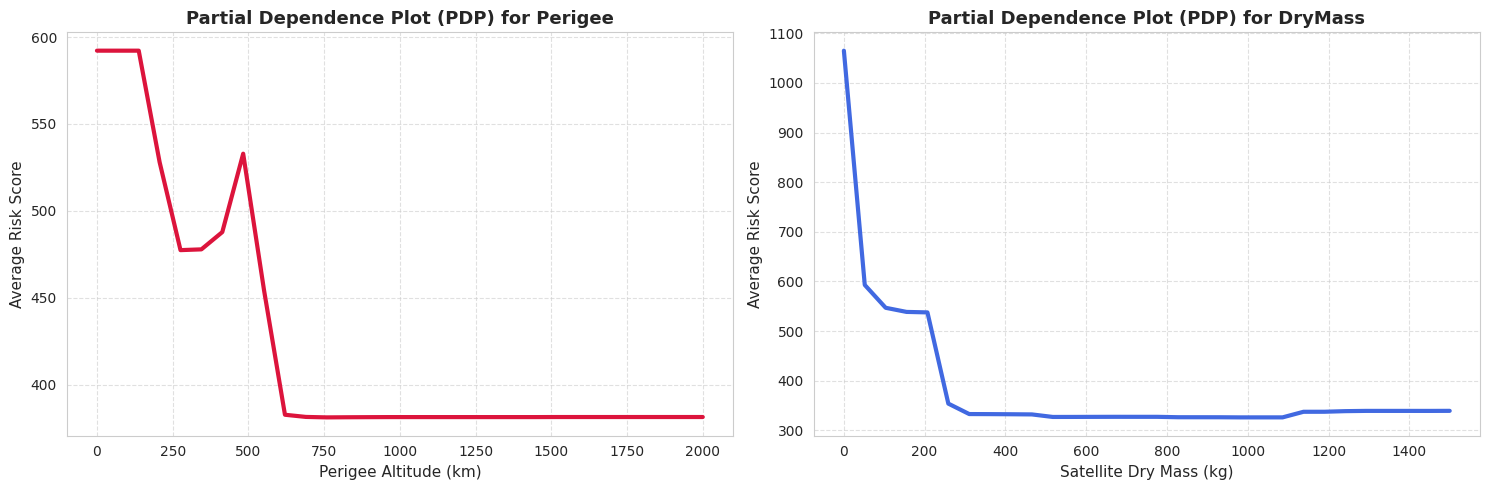

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare a stable subsample (2500 rows)
sample_size = min(2500, len(X_test))
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=sample_size, replace=False)
X_pdp = X_test.iloc[sample_indices].copy()

def calculate_pdp(feature_name, grid_points=30):
    """
    Calculates Partial Dependence values for a given feature
    """
    # Create a grid of values from the minimum to the 95th quantile (to prevent GEO from compressing the LEO graph to a point)
    # If it's perigee, the grid can be manually limited to 2000 km for LEO clarity,
    # or automatic selection can be left.
    if feature_name == 'Perigee':
        # Focus the grid on LEO/MEO (up to 2000 km) to analyze atmospheric physics
        grid = np.linspace(X_pdp[feature_name].min(), 2000, grid_points)
    else:
        grid = np.linspace(X_pdp[feature_name].min(), X_pdp[feature_name].quantile(0.95), grid_points)

    pdp_values = []

    # Temporary copy to avoid corrupting the original data
    X_temp = X_pdp.copy()

    for val in grid:
        # Strictly replace the feature value across the entire subsample
        X_temp[feature_name] = val

        # rsf.predict returns a risk score (the higher it is, the faster the satellite will 'die')
        preds = rsf.predict(X_temp)

        # Record the average risk across the entire sample for this feature value
        pdp_values.append(np.mean(preds))

    return grid, np.array(pdp_values)

# 2. Calculate dependencies
print("Calculating PDP for Perigee...")
perigee_grid, perigee_pdp = calculate_pdp('Perigee')

print("Calculating PDP for DryMass...")
mass_grid, mass_pdp = calculate_pdp('DryMass')

# 3. Visualization
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for Perigee
ax1.plot(perigee_grid, perigee_pdp, color='crimson', lw=3, label='PD Function')
ax1.set_title('Partial Dependence Plot (PDP) for Perigee', fontsize=13, fontweight='bold')
ax1.set_xlabel('Perigee Altitude (km)', fontsize=11)
ax1.set_ylabel('Average Risk Score', fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot for Mass
ax2.plot(mass_grid, mass_pdp, color='royalblue', lw=3, label='PD Function')
ax2.set_title('Partial Dependence Plot (PDP) for DryMass', fontsize=13, fontweight='bold')
ax2.set_xlabel('Satellite Dry Mass (kg)', fontsize=11)
ax2.set_ylabel('Average Risk Score', fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Calculating PDP for Apogee...
Calculating PDP for Span...


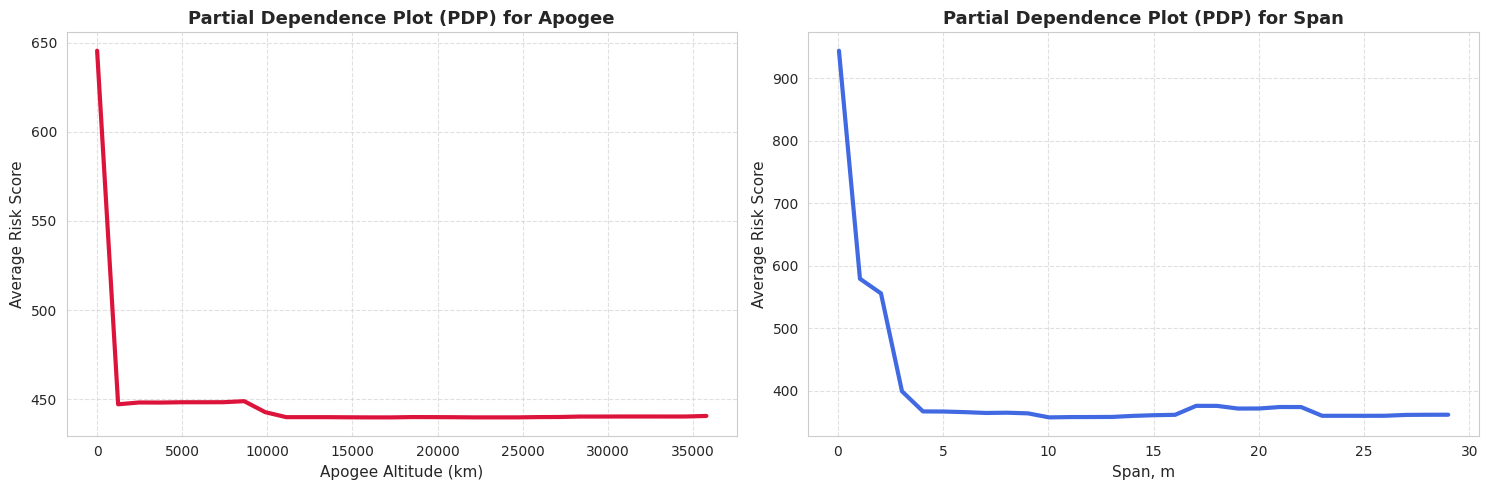

In [ ]:
print("Calculating PDP for Apogee...")
apogee_grid, apogee_pdp = calculate_pdp('Apogee')

print("Calculating PDP for Span...")
span_grid, span_pdp = calculate_pdp('Span')

# 3. Visualization
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for Perigee
ax1.plot(apogee_grid, apogee_pdp, color='crimson', lw=3, label='PD Function')
ax1.set_title('Partial Dependence Plot (PDP) for Apogee', fontsize=13, fontweight='bold')
ax1.set_xlabel('Apogee Altitude (km)', fontsize=11)
ax1.set_ylabel('Average Risk Score', fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot for Mass
ax2.plot(span_grid, span_pdp, color='royalblue', lw=3, label='PD Function')
ax2.set_title('Partial Dependence Plot (PDP) for Span', fontsize=13, fontweight='bold')
ax2.set_xlabel('Span, m', fontsize=11)
ax2.set_ylabel('Average Risk Score', fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Partial Dependence Plots

## All dataset

In [ ]:
import numpy as np
import pandas as pd
from sksurv.metrics import concordance_index_censored
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Automatically determine field names in your structured array y
status_field, duration_field = y_test.dtype.names
print(f"Fields defined in target: status = '{status_field}', time = '{duration_field}'")

X_sub = X_test.copy()
y_sub = y_test

print(f"Running step-by-step Permutation Importance on a sample of {len(X_sub)} rows...")

# 3. Calculate the base C-index of the model on the subsample
base_preds = rsf.predict(X_sub)
base_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], base_preds)[0]
print(f"Base C-index of the model on the subsample: {base_cindex:.4f}\n")

# 4. Run step-by-step feature traversal with logging
importances = {}
features = X_sub.columns.tolist()
total_features = len(features)

for idx, col in enumerate(features, 1):
    original_col = X_sub[col].copy()

    # Shuffle the feature
    X_sub[col] = np.random.permutation(X_sub[col].values)

    # Calculate score with the broken feature
    shuffled_preds = rsf.predict(X_sub)
    new_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], shuffled_preds)[0]

    # Calculate the delta of quality drop
    importances[col] = base_cindex - new_cindex

    X_sub[col] = original_col

    # Display status update every 10 features to see that the code is working
    if idx % 10 == 0 or idx == total_features:
        print(f"Progress: [{idx}/{total_features}] features processed... Current: {col}")

# 5. Collect results
importances_df = pd.DataFrame({
    'feature': importances.keys(),
    'weight': importances.values()
}).sort_values(by='weight', ascending=False)

Fields defined in target: status = 'Status', time = 'Time'
Running step-by-step Permutation Importance on a sample of 3798 rows...
Base C-index of the model on the subsample: 0.8718

Progress: [10/112] features processed... Current: OpOrbit_GTO
Progress: [20/112] features processed... Current: OpOrbit_LLEO/P
Progress: [30/112] features processed... Current: Launch_Site_GIK-1
Progress: [40/112] features processed... Current: Launch_Site_KASC
Progress: [50/112] features processed... Current: Launch_Site_PALB
Progress: [60/112] features processed... Current: Launch_Site_V
Progress: [70/112] features processed... Current: Shape_Box_with_Panels
Progress: [80/112] features processed... Current: Bus_Cubesat_1.5U
Progress: [90/112] features processed... Current: Bus_Cubesat_Other
Progress: [100/112] features processed... Current: Owner_NROC
Progress: [110/112] features processed... Current: Owner_ZLZB
Progress: [112/112] features processed... Current: Owner_ZZB


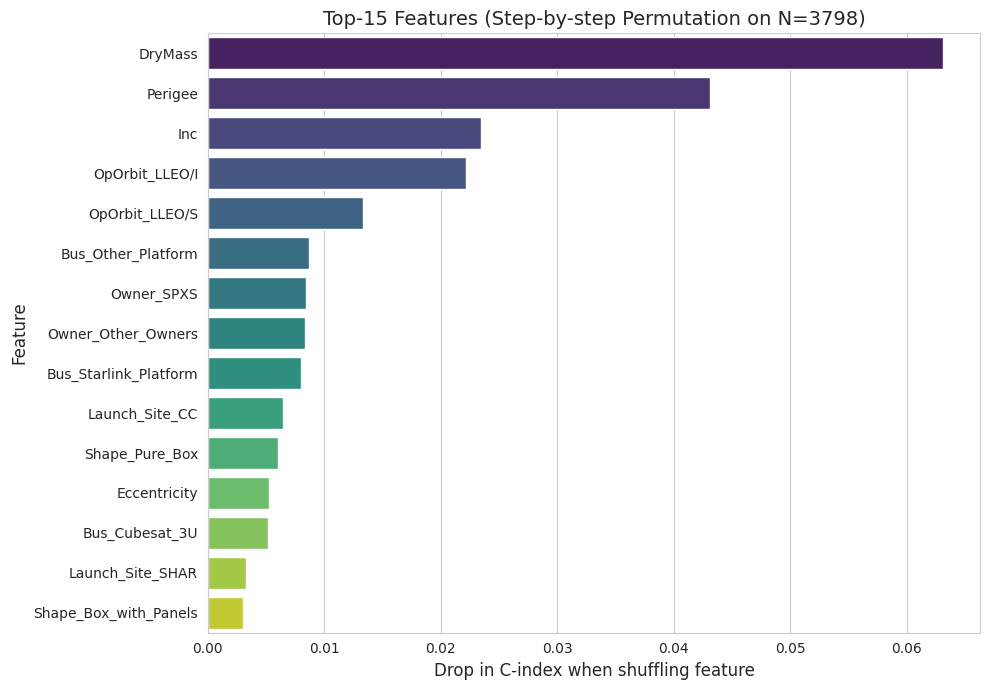


============== TOP-15 FEATURES ===============
              feature   weight
              DryMass 0.063134
              Perigee 0.043130
                  Inc 0.023471
       OpOrbit_LLEO/I 0.022161
       OpOrbit_LLEO/S 0.013348
   Bus_Other_Platform 0.008685
           Owner_SPXS 0.008454
   Owner_Other_Owners 0.008368
Bus_Starlink_Platform 0.007956
       Launch_Site_CC 0.006484
       Shape_Pure_Box 0.006023
         Eccentricity 0.005263
       Bus_Cubesat_3U 0.005180
     Launch_Site_SHAR 0.003264
Shape_Box_with_Panels 0.003035


In [ ]:
# 6. Final graph for TOP-15
top_fi = importances_df.head(15)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))
sns.barplot(
    x="weight",
    y="feature",
    data=top_fi,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title(f'Top-15 Features (Step-by-step Permutation on N={len(X_sub)})', fontsize=14)
plt.xlabel('Drop in C-index when shuffling feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n============== TOP-15 FEATURES ===============")
print(top_fi.to_string(index=False))

### Numerical features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_pdp = X_test.copy()

def calculate_pdp(feature_name, grid_points=30):
    """
    Calculates Partial Dependence values for a given feature
    """
    # Create a grid of values from the minimum to the 95th quantile (to prevent GEO from compressing the LEO graph to a point)
    # If it's perigee, the grid can be manually limited to 2000 km for LEO clarity,
    # or automatic selection can be left.
    if feature_name == 'Perigee':
        # Focus the grid on LEO/MEO (up to 2000 km) to analyze atmospheric physics
        grid = np.linspace(X_pdp[feature_name].min(), 2000, grid_points)
    else:
        grid = np.linspace(X_pdp[feature_name].min(), X_pdp[feature_name].quantile(0.95), grid_points)

    pdp_values = []

    # Temporary copy to avoid corrupting the original data
    X_temp = X_pdp.copy()

    for val in grid:
        # Strictly replace the feature value across the entire subsample
        X_temp[feature_name] = val

        # rsf.predict returns a risk score (the higher it is, the faster the satellite will 'die')
        preds = rsf.predict(X_temp)

        # Record the average risk across the entire sample for this feature value
        pdp_values.append(np.mean(preds))

    return grid, np.array(pdp_values)

# 2. Calculate dependencies
print("Calculating PDP for Perigee...")
perigee_grid, perigee_pdp = calculate_pdp('Perigee')

print("Calculating PDP for Dry Mass...")
mass_grid, mass_pdp = calculate_pdp('DryMass')

print("Calculating PDP for Inclination...")
inc_grid, inc_pdp = calculate_pdp('Inc')




Calculating PDP for Perigee...
Calculating PDP for Dry Mass...
Calculating PDP for Inclination...


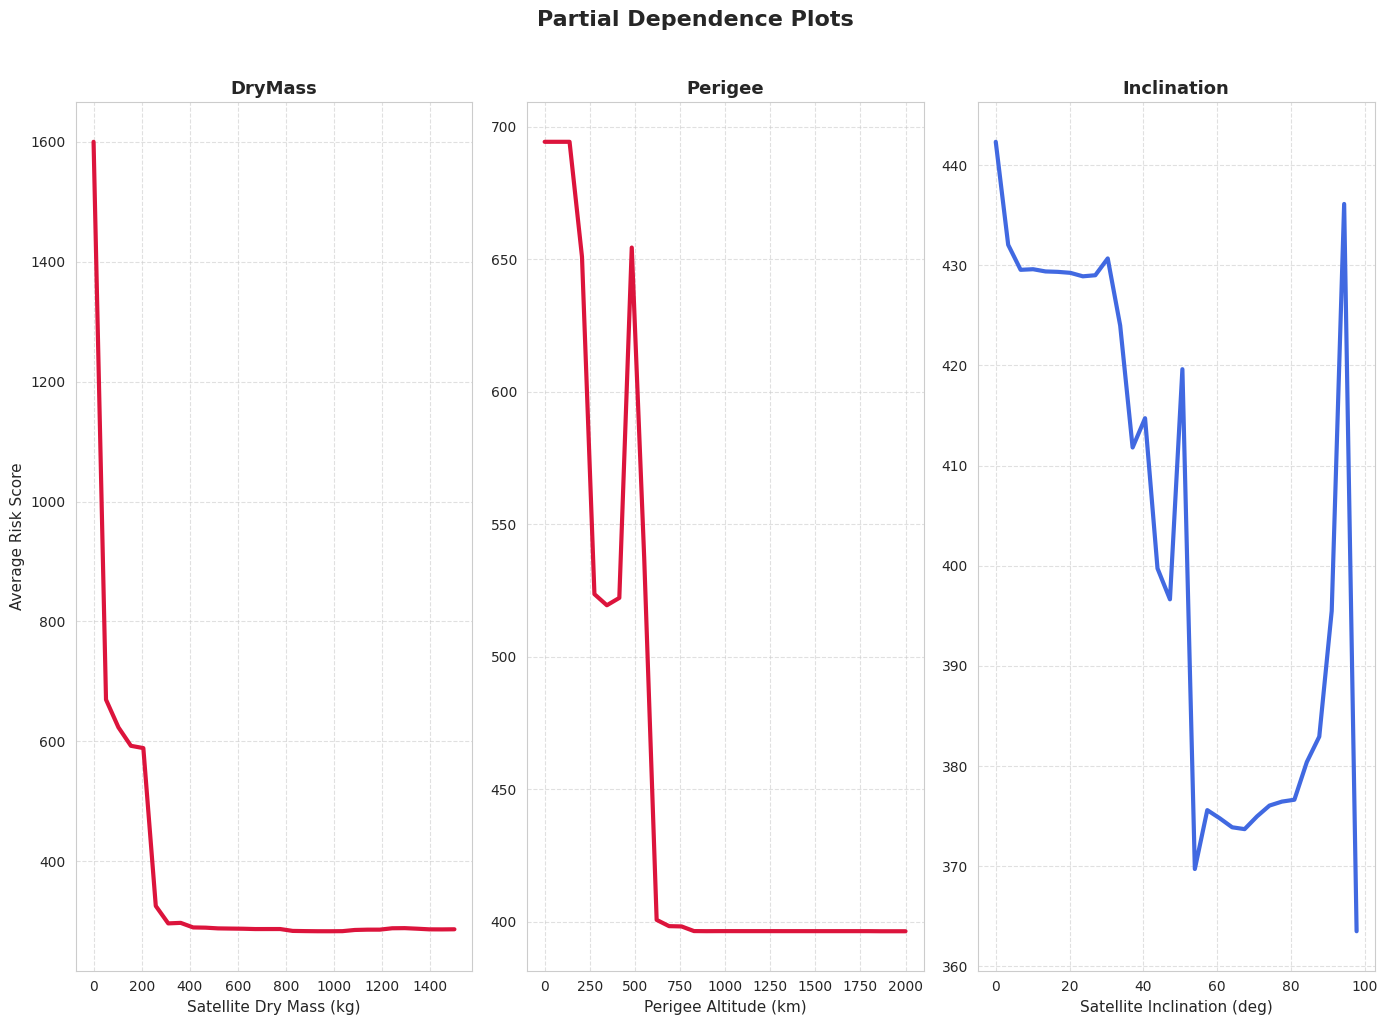

In [ ]:
# 3. Visualization

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 10))
axes = axes.flatten()

# Plot for Mass
axes[0].plot(mass_grid, mass_pdp, color='crimson', lw=3, label='PD Function')
axes[0].set_title('DryMass', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Satellite Dry Mass (kg)', fontsize=11)
axes[0].set_ylabel('Average Risk Score', fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot for Perigee
axes[1].plot(perigee_grid, perigee_pdp, color='crimson', lw=3, label='PD Function')
axes[1].set_title('Perigee', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Perigee Altitude (km)', fontsize=11)
#axes[1].set_ylabel('Average Risk Score', fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot for Inclination
axes[2].plot(inc_grid, inc_pdp, color='royalblue', lw=3, label='PD Function')
axes[2].set_title('Inclination', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Satellite Inclination (deg)', fontsize=11)
#axes[2].set_ylabel('Average Risk Score', fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.6)

# axes[3].plot(sym_grid, sym_pdp, color='royalblue', lw=3, label='PD Function')
# axes[3].set_title('Partial Dependence Plop (PDP) for SYM/H', fontsize=13, fontweight='bold')
# axes[3].set_xlabel('Satellite minimal SYM/H (nT)', fontsize=11)
# axes[3].set_ylabel('Average Risk Score', fontsize=11)
# axes[3].grid(True, linestyle="--", alpha=0.6)

plt.suptitle('Partial Dependence Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Non-Linear Risk Dynamics of Orbital Inclination

The Partial Dependence Plot (PDP) for Inclination exhibits a highly volatile, non-monotonic profile, which reflects socio-technical and geographical launch constraints rather than pure astrodynamical degradation.

* The Concurrency Peaks ($\approx 53^{\circ}$ and $97^{\circ}$–$98^{\circ}$): The sharp localized risk spikes correspond precisely to the most heavily populated orbital shells in modern astronautics. The drop and subsequent spike near $53^{\circ}$ captures the operational signature of massive commercial LEO constellations (e.g., Starlink programmatic recycling).

* The Polar Volatility Zone ($>90^{\circ}$): The extreme fluctuations in the $90^{\circ}$–$98^{\circ}$ range are driven by the Sun-synchronous orbit (SSO) regime. This sector suffers from high mathematical variance in the model due to the co-existence of two radically different satellite classes sharing identical geometric channels: highly vulnerable, non-propulsive academic CubeSats and long-lived institutional remote sensing platforms.

Consequently, the RSF model treats Inclination as a high-fidelity proxy for institutional mission intent and fleet deployment strategies, mapping specific operational risk architectures to rigid, discrete launch windows.

### Categorical features

NameError: name 'rsf' is not defined

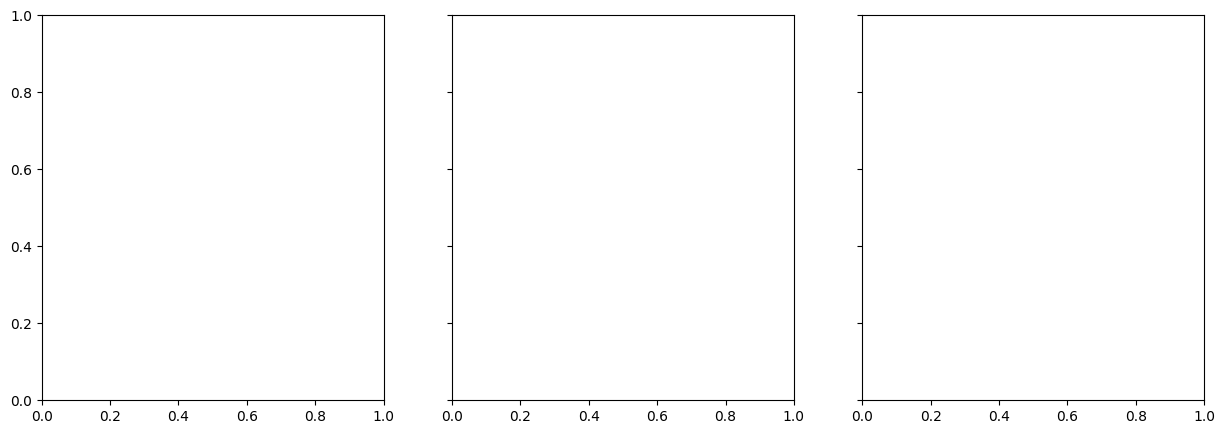

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# List of your binary platform features (pass exact names from X_train_final)
bus_features = [
    'Clean_Bus_Starlink_Platform',
    'Clean_Bus_Cubesat_3U',
    'Clean_Bus_Other_Platform'
]

# Set up a grid of plots
fig, axes = plt.subplots(1, len(bus_features), figsize=(15, 5), sharey=True)

# Plot PDP
display = PartialDependenceDisplay.from_estimator(
    rsf,                          # Your trained final RSF model
    X_test_final,                 # Cleaned test dataset
    features=bus_features,
    ax=axes,
    kind="average"                # Calculate only the global average PDP
)

# Make plots more readable
for i, ax in enumerate(axes):
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No (0)', 'Yes (1)'], fontsize=11)
    ax.set_title(bus_features[i].replace('Clean_Bus_', ''), fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Risk Score')

plt.suptitle('Partial Dependence Plots (PDP) for platform types', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_binary_pdp(model, X_data, feature_name):
    """ Manually calculates the average marginal risk for 0 and 1 """
    # Create two copies of the dataset
    X_0 = X_data.copy()
    X_1 = X_data.copy()

    # Force set the feature value to zero and one for ALL objects
    X_0[feature_name] = 0
    X_1[feature_name] = 1

    # Get model predictions (integral risk)
    # For scikit-survival, this is usually the predict() method
    risk_0 = model.predict(X_0).mean()
    risk_1 = model.predict(X_1).mean()

    return risk_0, risk_1

# Collect data for all platforms of interest
bus_features = ['Clean_Bus_Starlink_Platform', 'Clean_Bus_Cubesat_3U', 'Clean_Bus_Other_Platform']
pdp_results = []

for feature in bus_features:
    r0, r1 = calculate_binary_pdp(rsf, X_test_final, feature)
    pdp_results.append({'Platform': feature.replace('Clean_Bus_', ''), 'Status': 'Baseline (0)', 'Risk': r0})
    pdp_results.append({'Platform': feature.replace('Clean_Bus_', ''), 'Status': 'Active (1)', 'Risk': r1})

pdp_df = pd.DataFrame(pdp_results)

# Plot a comparative Barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=pdp_df,
    x='Platform',
    y='Risk',
    hue='Status',
    palette=['#b0c4de', '#4682b4']
)

plt.title('Marginal influence of platform on risk level (Custom PDP)', fontsize=13, fontweight='bold')
plt.xlabel('Satellite platform type', fontsize=11)
plt.ylabel('Average Risk Score (Lower = More Durable)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Feature Presence')
plt.tight_layout()
plt.show()

NameError: name 'rsf' is not defined

## Survival Plot

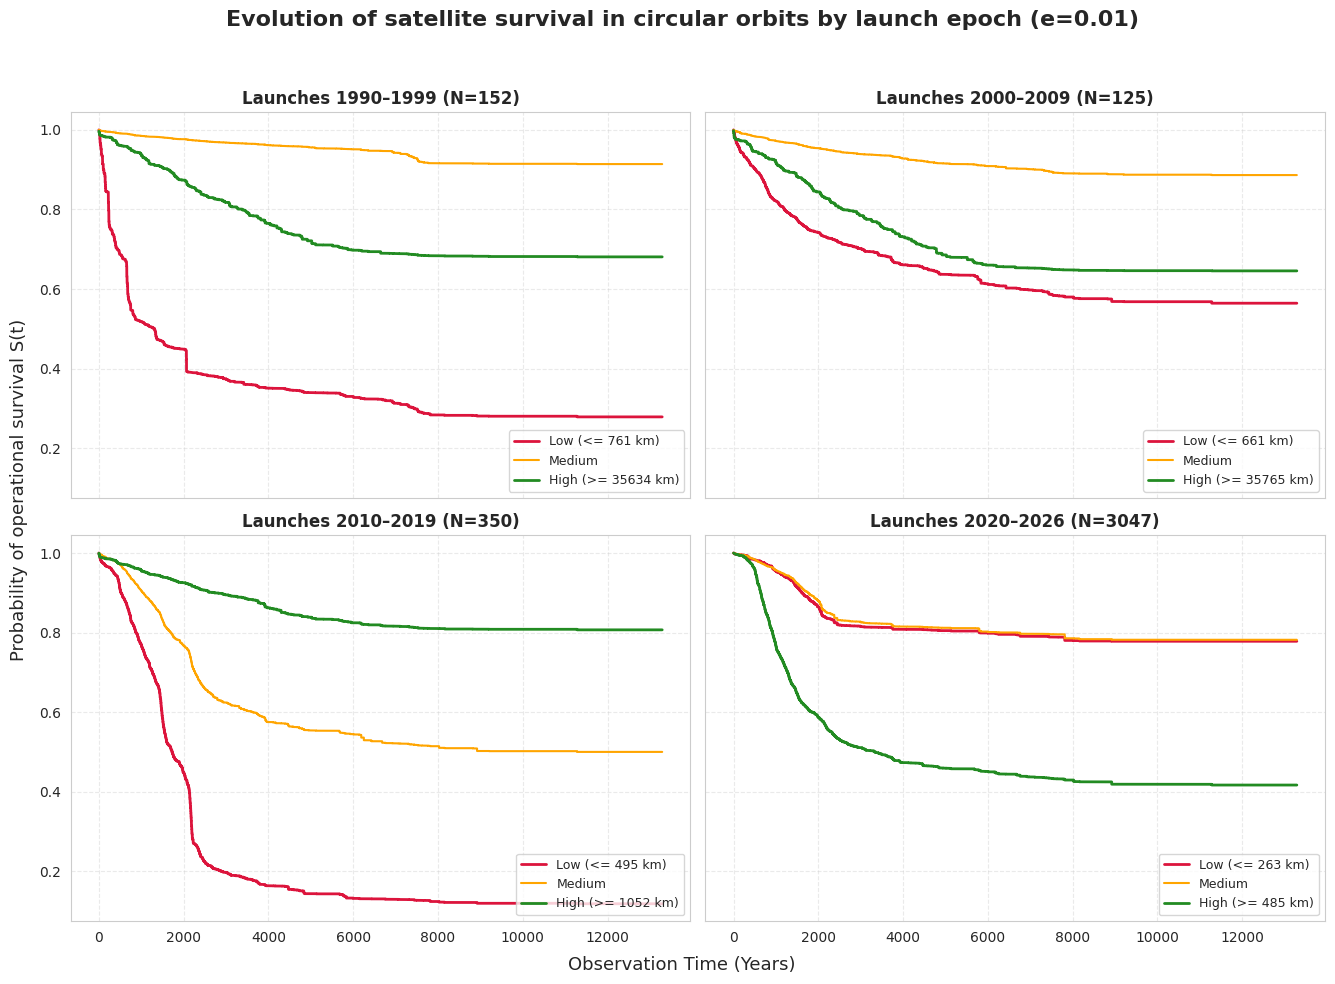

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming that in the original df_clean the year column is named 'Launch_Year'
# (if it's a full date, replace with pd.to_datetime(df_clean['Launch_Date']).dt.year)
X_test_with_year = X_test.copy()
X_test_with_year['Launch_Year'] = pd.to_datetime(df_clean.loc[X_test.index, 'LDate']).dt.year

# Set up a 2x2 grid for plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Define our 4 epochs (up to and including 2026)
epochs = [
    ("1990–1999", 1990, 1999),
    ("2000–2009", 2000, 2009),
    ("2010–2019", 2010, 2019),
    ("2020–2026", 2020, 2026)
]
# Get overall model predictions to calculate the time scale
surv_funcs = rsf.predict_survival_function(X_test)
times = surv_funcs[0].x

for i, (name, start_y, end_y) in enumerate(epochs):
    # Filter ONLY circular orbits within a specific epoch
    epoch_mask = (X_test_with_year['Launch_Year'] >= start_y) & \
                 (X_test_with_year['Launch_Year'] <= end_y) & \
                  (X_test_with_year['Eccentricity'] <= 0.01)

    X_epoch = X_test_with_year[epoch_mask]

    if len(X_epoch) < 10:
        axes[i].text(0.5, 0.5, f"Not enough data for {name}", ha='center', va='center')
        axes[i].set_title(f"Epoch: {name}")
        continue

    # Calculate perigee quantiles STRICTLY within this epoch
    low_val = X_epoch['Perigee'].quantile(0.25)
    high_val = X_epoch['Perigee'].quantile(0.75)

    idx_low = X_epoch[X_epoch['Perigee'] <= low_val].index
    idx_high = X_epoch[X_epoch['Perigee'] >= high_val].index
    idx_mid = X_epoch[(X_epoch['Perigee'] > low_val) & (X_epoch['Perigee'] < high_val)].index

    # Convert to positions for surv_funcs
    pos_low = [X_test.index.get_loc(idx) for idx in idx_low]
    pos_mid = [X_test.index.get_loc(idx) for idx in idx_mid]
    pos_high = [X_test.index.get_loc(idx) for idx in idx_high]

    # Average the curves
    surv_low = np.mean([f(times) for idx, f in enumerate(surv_funcs) if idx in pos_low], axis=0)
    surv_mid = np.mean([f(times) for idx, f in enumerate(surv_funcs) if idx in pos_mid], axis=0)
    surv_high = np.mean([f(times) for idx, f in enumerate(surv_funcs) if idx in pos_high], axis=0)

    # Plot subplot
    axes[i].step(times, surv_low, where="post", color="crimson", lw=2, label=f"Low (<= {low_val:.0f} km)")
    axes[i].step(times, surv_mid, where="post", color="orange", lw=1.5, label="Medium")
    axes[i].step(times, surv_high, where="post", color="forestgreen", lw=2, label=f"High (>= {high_val:.0f} km)")

    axes[i].set_title(f"Launches {name} (N={len(X_epoch)})", fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle="--", alpha=0.4)
    axes[i].legend(fontsize=9, loc="lower right")

# Overall captions for the entire grid
fig.suptitle("Evolution of satellite survival in circular orbits by launch epoch (e=0.01)", fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.02, "Observation Time (Years)", ha='center', fontsize=13)
fig.text(0.02, 0.5, "Probability of operational survival S(t)", va='center', rotation='vertical', fontsize=13)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.show()

## Extra

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_survival_by_feature(feature_name, q_low=0.25, q_high=0.75):
    """
    The function takes the test set, divides it into 3 groups by quantiles of the selected feature
    and plots the averaged survival curves for them.
    """
    # Determine quantile boundaries
    low_val = X_test[feature_name].quantile(q_low)
    high_val = X_test[feature_name].quantile(q_high)

    # Divide the test sample into three groups
    idx_low = X_test[X_test[feature_name] <= low_val].index
    idx_high = X_test[X_test[feature_name] >= high_val].index
    idx_mid = X_test[(X_test[feature_name] > low_val) & (X_test[feature_name] < high_val)].index

    # Find their ordinal numbers in X_test (to pass to the model)
    pos_low = [X_test.index.get_loc(i) for i in idx_low if i in X_test.index]
    pos_mid = [X_test.index.get_loc(i) for i in idx_mid if i in X_test.index]
    pos_high = [X_test.index.get_loc(i) for i in idx_high if i in X_test.index]

    # Get survival functions from RSF for the entire test set
    # The function returns an array of StepFunction objects
    surv_funcs = rsf.predict_survival_function(X_test)

    # Extract the time scale (same for all) and convert to years
    times_years = surv_funcs[0].x / 365.25

    # Average survival probabilities by groups
    surv_low = np.mean([f(times_years * 365.25) for i, f in enumerate(surv_funcs) if i in pos_low], axis=0)
    surv_mid = np.mean([f(times_years * 365.25) for i, f in enumerate(surv_funcs) if i in pos_mid], axis=0)
    surv_high = np.mean([f(times_years * 365.25) for i, f in enumerate(surv_funcs) if i in pos_high], axis=0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.step(times_years, surv_low, where="post", label=f"Low values (<={low_val:.1f})", color="crimson", lw=2)
    plt.step(times_years, surv_mid, where="post", label=f"Medium values", color="orange", lw=2)
    plt.step(times_years, surv_high, where="post", label=f"High values (>={high_val:.1f})", color="forestgreen", lw=2)

    plt.title(f"Influence of feature '{feature_name}' on satellite survival", fontsize=12)
    plt.xlabel("Observation Time (Years)", fontsize=10)
    plt.ylabel("Survival probability $S(t)$", fontsize=10)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# Run sequentially for the main features:
plot_survival_by_feature('Perigee')
plot_survival_by_feature('DryMass')
plot_survival_by_feature('Inc')

NameError: name 'X_test' is not defined

In [ ]:
X_test

,DryMass,Length,Diameter,Span,OrbPay,Perigee,Inc,Eccentricity,OpOrbit_GEO/I,OpOrbit_GEO/ID,...,Clean_State_OTHERS,Clean_State_RU,Clean_State_SG,Clean_State_SU,Clean_State_TR,Clean_State_TW,Clean_State_UAE,Clean_State_UK,Clean_State_US,Clean_State_UY
42,60.0,0.8,0.8,0.8,0.480,1462,73.98,0.000765,False,False,...,False,False,False,True,False,False,False,False,False,False
10422,700.0,0.3,4.1,29.0,17.250,283,43.01,0.000525,False,False,...,False,False,False,False,False,False,False,False,True,False
438,402.0,6.7,2.2,6.7,4.310,35763,0.07,0.000557,False,False,...,True,False,False,False,False,False,False,False,False,False
11930,700.0,0.3,4.1,29.0,17.250,285,43.01,0.000525,False,False,...,False,False,False,False,False,False,False,False,True,False
2008,1.0,0.1,0.1,0.1,0.354,658,98.13,0.000923,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2081,14.0,0.2,0.2,0.2,0.732,593,97.80,0.004285,False,False,...,False,False,False,False,False,False,False,False,True,False
18205,530.0,0.3,4.1,29.0,16.100,259,43.00,0.000602,False,False,...,False,False,False,False,False,False,False,False,True,False
1959,895.0,4.0,2.0,8.0,0.940,673,98.20,0.000567,False,False,...,False,False,False,False,False,False,False,False,False,False
14761,530.0,0.3,4.1,29.0,17.500,273,43.00,0.000225,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define mask only for circular orbits (eccentricity close to 0)
# ATTENTION: check column name, if you left 'True_Eccentricity', replace here
circular_mask = X_test['Eccentricity'] <= 0.0001

X_test_circular = X_test[circular_mask]
y_test_circular = y_test[circular_mask]

print(f"Size of filtered test sample (circular only): {X_test_circular.shape[0]} rows")

# 2. Determine perigee quantiles strictly within circular orbits
low_val = X_test_circular['Perigee'].quantile(0.25)
high_val = X_test_circular['Perigee'].quantile(0.75)

# Divide circular orbits into groups by height
idx_low = X_test_circular[X_test_circular['Perigee'] <= low_val].index
idx_high = X_test_circular[X_test_circular['Perigee'] >= high_val].index
idx_mid = X_test_circular[(X_test_circular['Perigee'] > low_val) & (X_test_circular['Perigee'] < high_val)].index

# Find their ordinal numbers in the original X_test, as we will call rsf.predict_survival_function for all
pos_low = [X_test.index.get_loc(i) for i in idx_low]
pos_mid = [X_test.index.get_loc(i) for i in idx_mid]
pos_high = [X_test.index.get_loc(i) for i in idx_high]

# 3. Predict survival curves (for the entire sample, so as not to break indices)
surv_funcs = rsf.predict_survival_function(X_test)
times_years = surv_funcs[0].x / 365.25 # Convert to years

# Average only for selected positions of circular orbits
surv_low = np.mean([f(times_years * 365.25) for i, f in enumerate(surv_funcs) if i in pos_low], axis=0)
surv_mid = np.mean([f(times_years * 365.25) for i, f in enumerate(surv_funcs) if i in pos_mid], axis=0)
surv_high = np.mean([f(times_years * 365.25) for i, f in enumerate(surv_funcs) if i in pos_high], axis=0)

# 4. Visualization
plt.figure(figsize=(9, 6))
plt.step(times_years, surv_low, where="post", label=f"Low perigee LEO (<={low_val:.1f} km)", color="crimson", lw=2)
plt.step(times_years, surv_mid, where="post", label=f"Medium perigee", color="orange", lw=2)
plt.step(times_years, surv_high, where="post", label=f"High perigee GEO/MEO (>={high_val:.1f} km)", color="forestgreen", lw=2)

plt.title("Influence of 'Perigee' on circular orbits (e <= 0.01)", fontsize=14)
plt.xlabel("Observation Time (Years)", fontsize=12)
plt.ylabel("Survival probability $S(t)$", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

NameError: name 'X_test' is not defined

## Kaplan-Meier